# 📘 Bölüm 8: Gözetimsiz Öğrenme Teknikleri(Unsupervised Learning)
### *Hands-On Machine Learning with Scikit-Learn and PyTorch — Türkçe Açıklamalı Notebook*

---

> **Yann LeCun'ın ünlü sözü:**  
> *"Eğer zeka bir pasta olsaydı, gözetimsiz öğrenme pastanın kendisi, gözetimli öğrenme pastanın kreması, pekiştirmeli öğrenme ise üstündeki kiraz olurdu."*

Bu bölümde şu konuları öğreneceğiz:
1. **Kümeleme (Clustering)** — k-means ve DBSCAN algoritmaları
2. **Anomali Tespiti (Anomaly Detection)**
3. **Yoğunluk Tahmini (Density Estimation)**
4. **Gaussian Karışım Modelleri (Gaussian Mixture Models)**

---

## 🔧 Gerekli Kütüphanelerin Kurulumu ve İçe Aktarımı

In [1]:
# Gerekli kütüphaneleri içe aktar
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, load_digits
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("✅ Tüm kütüphaneler başarıyla yüklendi!")

✅ Tüm kütüphaneler başarıyla yüklendi!


---

## 📌 Bölüm 1: Gözetimsiz Öğrenmeye Giriş (Unsupervised Learning)

### Neden Gözetimsiz Öğrenme?

Günümüzde makine öğrenmesi uygulamalarının büyük çoğunluğu gözetimli öğrenme üzerine kuruludur. Ancak mevcut verinin **büyük çoğunluğu etiketlenmemiş** durumdadır.

**Gerçek Hayat Örneği:**  
Bir üretim hattında her gün binlerce ürün fotoğrafı çekildiğini düşünün. Bu fotoğrafları "hatalı" veya "normal" olarak etiketlemek için insan uzman gerektirir — bu hem pahalı hem de yavaş bir süreçtir. İşte bu noktada **gözetimsiz öğrenme** devreye girer!

### Temel Gözetimsiz Öğrenme Görevleri:

| Görev | Açıklama | Kullanım Alanı |
|-------|----------|----------------|
| **Kümeleme** | Benzer örnekleri gruplama | Müşteri segmentasyonu, görüntü bölütleme |
| **Anomali Tespiti** | Anormal örnekleri bulma | Dolandırıcılık tespiti, kalite kontrol |
| **Yoğunluk Tahmini** | Olasılık dağılımını tahmin etme | Veri analizi, görselleştirme |

### Etiketli ve Etiketsiz Veriyi Görselleştirme

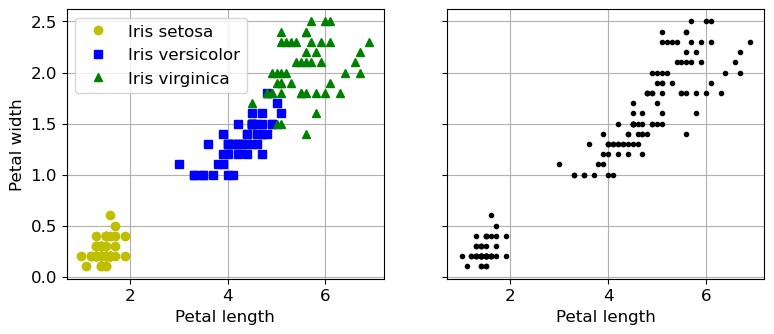

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

data = load_iris()
X = data.data    # 150 örnek x 4 özellik
y = data.target  # 0, 1, 2 → iris türleri

plt.figure(figsize=(9, 3.5))

# Sol: Etiketli sınıflandırma verisi
plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

# Sağ: Etiketsiz kümeleme verisi
plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

**📌 Satır satır açıklama:**

```python
data = load_iris()
X = data.data          # 150 örnek × 4 özellik (sepal/petal uzunluk ve genişlik)
y = data.target        # 0, 1, 2 → iris türleri
```

```python
plt.subplot(121)   # 1 satır x 2 sütun ızgaranın 1. hücresi → sol grafik
```

```python
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
```
- `X[y==0, 2]` → Setosa türüne ait tüm örneklerin 3. özelliği (taç yaprak uzunluğu, indeks 2)
- `X[y==0, 3]` → Aynı örneklerin 4. özelliği (taç yaprak genişliği, indeks 3)
- `"yo"` → Sarı renk (y) + daire marker (o)

```python
plt.tick_params(labelleft=False)
```
Sol grafik zaten y ekseni etiketine sahip olduğundan, sağ grafik için y ekseni sayılarını gizle.

```python
plt.gca().set_axisbelow(True)
```
`gca()` = "get current axes". `set_axisbelow(True)` → Izgara çizgilerini veri noktalarının **altında** göster.

---

## 📌 Bölüm 2: Kümeleme Algoritmaları

### Kümeleme Nedir?

**Kümeleme**, benzer örnekleri bir araya getirerek **kümeler (clusters)** oluşturma görevidir. Sınıflandırmaya benzer görünse de temel fark şudur: Kümelemede **etiket yoktur**, algoritma kendi kendine grupları keşfetmek zorundadır.

### Kümelemenin Kullanım Alanları:

1. **Müşteri Segmentasyonu:** Satın alma alışkanlıklarına göre müşterileri gruplama → özelleştirilmiş pazarlama
2. **Veri Analizi:** Yeni veri setlerini keşfetmek için her kümeyi ayrı ayrı analiz etme
3. **Boyut İndirgeme:** Her örnek için kümeye olan benzerlik (affinity) skoru yeni özellikler olabilir
4. **Özellik Mühendisliği:** Küme benzerlik skorları ek özellik olarak kullanılabilir
5. **Anomali Tespiti:** Hiçbir kümeye benzemeyenler anomali adayıdır
6. **Yarı-Gözetimli Öğrenme:** Az etiketli örnekleri kümedeki tüm örneklere yayma
7. **Arama Motorları:** Benzer görüntüleri bulmak için
8. **Görüntü Bölütleme:** Renklere göre pikselleri gruplama

### GMM ile Küme-Sınıf Eşlemesi

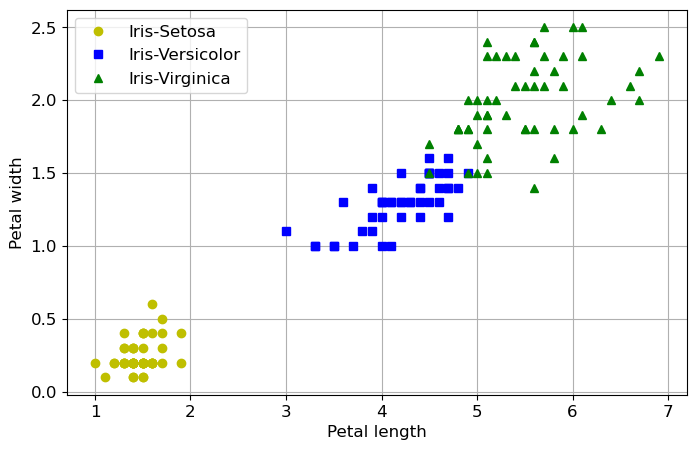

Doğruluk: 0.9667


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture

# GMM Modelini eğit ve tahminleri al
y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

# Küme indekslerini gerçek sınıf etiketlerine eşle
mapping = {}
for class_id in np.unique(y):
    # keepdims=True ve yeni dönüş tipine uygun indeksleme:
    mode_res = stats.mode(y_pred[y == class_id], keepdims=True)
    # mode_res.mode[0] bize array içindeki değeri verir
    cluster_id = mode_res.mode[0]
    mapping[cluster_id] = class_id

# Tahmin edilen küme numaralarını gerçek etiketlere çevir
y_pred_mapped = np.array([mapping[cluster_id] for cluster_id in y_pred])

# Görselleştirme (y_pred_mapped kullanarak)
plt.figure(figsize=(8, 5))
plt.plot(X[y_pred_mapped==0, 2], X[y_pred_mapped==0, 3], "yo", label="Iris-Setosa")
plt.plot(X[y_pred_mapped==1, 2], X[y_pred_mapped==1, 3], "bs", label="Iris-Versicolor")
plt.plot(X[y_pred_mapped==2, 2], X[y_pred_mapped==2, 3], "g^", label="Iris-Virginica")

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Doğruluk oranı
accuracy = (y_pred_mapped == y).sum() / len(y)
print(f"Doğruluk: {accuracy:.4f}")

**📌 Satır satır açıklama:**

```python
y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)
```
Tek satırda: GMM oluştur → eğit → tahmin et. GMM kümeler bulur ama küme indeksleri rastgeledir (0,1,2 yerine 2,0,1 çıkabilir).

```python
for class_id in np.unique(y):           # 0, 1, 2 için döngü
    mode, _ = stats.mode(y_pred[y==class_id])
    mapping[mode] = class_id
```
**Küme-sınıf eşleme algoritması:**
- `y==class_id` → Gerçek sınıfı `class_id` olan örneklerin boolean maskesi
- `y_pred[y==class_id]` → Bu örneklere GMM hangi küme indeksini atadı?
- `stats.mode(...)` → En sık görülen küme indeksi (mod) → Bu küme, bu sınıfa karşılık gelir

```python
y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])
```
List comprehension ile tüm küme indekslerini gerçek sınıf etiketlerine dönüştür.

```python
(y_pred == y).sum() / len(y_pred)    # Sonuç ~0.967 → %96.7 doğruluk
```

---

## 📌 Bölüm 3: K-Means Algoritması

### K-Means Nedir?

**K-Means**, en popüler kümeleme algoritmalarından biridir. 1957 yılında Stuart Lloyd tarafından Bell Labs'ta geliştirilmiş ve 1982'de yayımlanmıştır. Bazen **Lloyd-Forgy algoritması** olarak da anılır.

**Temel fikir:** Veri noktalarını *k* adet kümeye ayır; her nokta en yakın küme merkezine (centroid) atansın.

### K-Means Nasıl Çalışır?

1. **Başlangıç:** k adet merkez (centroid) rastgele seç
2. **Atama Adımı:** Her örneği en yakın merkeze ata
3. **Güncelleme Adımı:** Her kümenin ortalamasını alarak yeni merkezleri hesapla
4. **Tekrar:** Merkezler değişmeyene kadar 2 ve 3. adımları tekrarla

In [2]:
# Örnek veri seti oluştur - 5 kümeli yapay veri
np.random.seed(42)
blob_centers = np.array([[-3, 2], [-1, 2], [0, 0], [2, 2], [3, 1]])
blob_std = np.array([0.4, 0.3, 0.3, 0.2, 0.3])

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

# K-Means modelini eğit
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

print("📊 K-Means Sonuçları:")
print(f"  Tahmin edilen etiketler (ilk 10): {y_pred[:10]}")
print(f"  Küme merkezleri:\n{kmeans.cluster_centers_.round(2)}")
print(f"  Inertia (atalet): {kmeans.inertia_:.2f}")

📊 K-Means Sonuçları:
  Tahmin edilen etiketler (ilk 10): [1 3 0 1 3 4 0 4 2 1]
  Küme merkezleri:
[[-0.97  2.02]
 [ 2.    2.  ]
 [-0.02  0.02]
 [-3.02  2.  ]
 [ 3.02  0.99]]
  Inertia (atalet): 369.10


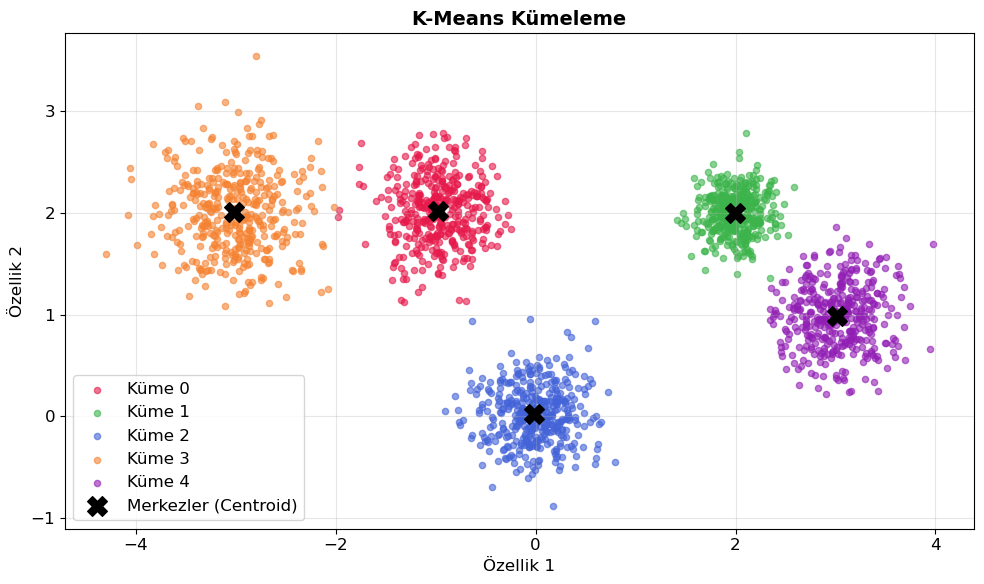

In [3]:
# Kümeleme sonuçlarını görselleştir
def plot_clusters(X, y_pred, centers, title="K-Means Kümeleme"):
    colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    plt.figure(figsize=(10, 6))
    for i in range(k):
        plt.scatter(X[y_pred == i, 0], X[y_pred == i, 1],
                    c=colors[i], alpha=0.6, label=f'Küme {i}', s=20)
    plt.scatter(centers[:, 0], centers[:, 1],
                c='black', s=200, marker='X', label='Merkezler (Centroid)', zorder=5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Özellik 1')
    plt.ylabel('Özellik 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_clusters(X, y_pred, kmeans.cluster_centers_)

In [4]:
# Yeni örnekler için tahmin
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print("🔮 Yeni örnekler için küme tahminleri:")
print(f"  Tahmin edilen kümeler: {kmeans.predict(X_new)}")

# Her kümeye olan mesafe (soft clustering - yumuşak kümeleme)
print("\n📏 Her örneğin her küme merkezine uzaklığı:")
print(kmeans.transform(X_new).round(2))
print("\n💡 Bu özellik, yüksek boyutlu verilerde boyut indirgeme için kullanılabilir!")

🔮 Yeni örnekler için küme tahminleri:
  Tahmin edilen kümeler: [0 1 3 3]

📏 Her örneğin her küme merkezine uzaklığı:
[[0.97 2.   1.98 3.02 3.18]
 [3.97 1.   3.6  6.02 1.01]
 [2.25 5.1  4.21 1.   6.35]
 [2.08 5.02 3.88 0.5  6.21]]

💡 Bu özellik, yüksek boyutlu verilerde boyut indirgeme için kullanılabilir!


### Karar Sınırları için Yardımcı Fonksiyonlar

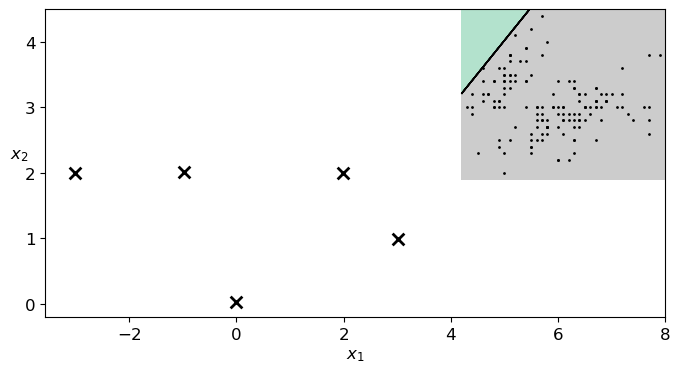

In [29]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

**📌 Fonksiyon detaylı açıklamaları:**

#### `plot_centroids(centroids, weights=None, ...)`
```python
if weights is not None:
    centroids = centroids[weights > weights.max() / 10]
```
GMM gibi modellerde çok küçük ağırlıklı (önemsiz) centroid'leri filtrele.

```python
plt.scatter(..., marker='o', s=35, linewidths=8, color=circle_color, zorder=10)
plt.scatter(..., marker='x', s=2,  linewidths=12, color=cross_color, zorder=11)
```
Centroid'leri ⊗ sembolüyle göster: önce büyük beyaz daire (zemin), üstüne siyah çarpı (X). `zorder` → çizim sırası (büyük = üste).

#### `plot_decision_boundaries(clusterer, X, ...)`

```python
xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution), ...)
```
1000×1000 = 1.000.000 noktalık ızgara oluştur.

```python
Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
```
- `xx.ravel()` → 2D ızgara → 1D dizi (1.000.000 eleman)
- `np.c_[...]` → İki diziyi yan yana koyarak `(1.000.000, 2)` matris yap
- `predict()` → Her ızgara noktasına küme etiketi atanır

```python
plt.contourf(...)   # Dolu kontur → Voronoi bölgeleri renkli
plt.contour(...)    # Sadece sınır çizgileri siyah
```

### 🔍 Sert ve Yumuşak Kümeleme

| Tür | Açıklama | Yöntem |
|-----|----------|--------|
| **Sert Kümeleme** (Hard) | Her örnek yalnızca 1 kümeye atanır | `predict()` |
| **Yumuşak Kümeleme** (Soft) | Her örnek için her kümeye bir skor/mesafe hesaplanır | `transform()` |

### Yumuşak Kümeleme: transform() ile Mesafeler

In [31]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Veri ve Model Hazırlığı
# Örnek veri seti oluşturalım
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=0.60, random_state=42)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# Test için yeni örnekler (4 adet veri noktası)
X_new = np.array([
    [0, 2],
    [3, 2],
    [-3, 3],
    [-3, 9]
])

# 2. Scikit-Learn ile Mesafe Hesaplama (transform metodu)
print("K-Means Transform (İlk 4 Örnek):")
distances_sklearn = kmeans.transform(X_new)
print(distances_sklearn.round(2))

# 3. Manuel Doğrulama: NumPy Broadcasting ile Öklid Mesafesi
# X_new: (4, 2) -> (4, 1, 2) formatına getirilir
# kmeans.cluster_centers_: (5, 2)
# Çıkarma işlemi sonucunda her nokta her merkezle eşleşir: (4, 5, 2)
manuel = np.linalg.norm(X_new[:, np.newaxis, :] - kmeans.cluster_centers_, axis=2)

print("\nManuel Hesap (Broadcasting ile):")
print(manuel.round(2))

# 4. Kontrol: İki sonucun aynı olup olmadığını teyit et
is_same = np.allclose(distances_sklearn, manuel)
print(f"\nSonuçlar birbirine eşit mi? {is_same}")

K-Means Transform (İlk 4 Örnek):
[[ 4.58 10.31 11.21  7.43  2.91]
 [ 1.58 12.98 13.23  8.93  2.32]
 [ 7.63  7.26 10.62  5.98  5.13]
 [10.26  6.08 16.37  0.41  7.01]]

Manuel Hesap (Broadcasting ile):
[[ 4.58 10.31 11.21  7.43  2.91]
 [ 1.58 12.98 13.23  8.93  2.32]
 [ 7.63  7.26 10.62  5.98  5.13]
 [10.26  6.08 16.37  0.41  7.01]]

Sonuçlar birbirine eşit mi? True


---

### 3.1 K-Means Algoritmasının Detayları

**Algoritmanın işleyişi:**
- Merkezler rastgele başlatılır
- Örnekler en yakın merkeze atanır
- Merkezler, kümelerindeki örneklerin ortalamasıyla güncellenir
- Bu döngü yakınsayana kadar devam eder

**Hesaplama Karmaşıklığı:** Genellikle **O(m × k × n)** — m: örnek sayısı, k: küme sayısı, n: boyut sayısı

**Önemli Uyarı:** Algoritma lokal minimuma takılabilir! Bu nedenle `n_init` parametresi ile birden fazla rastgele başlangıçla çalıştırılır.

## K-Means Algoritması Adım Adım Görseleştirilmesi

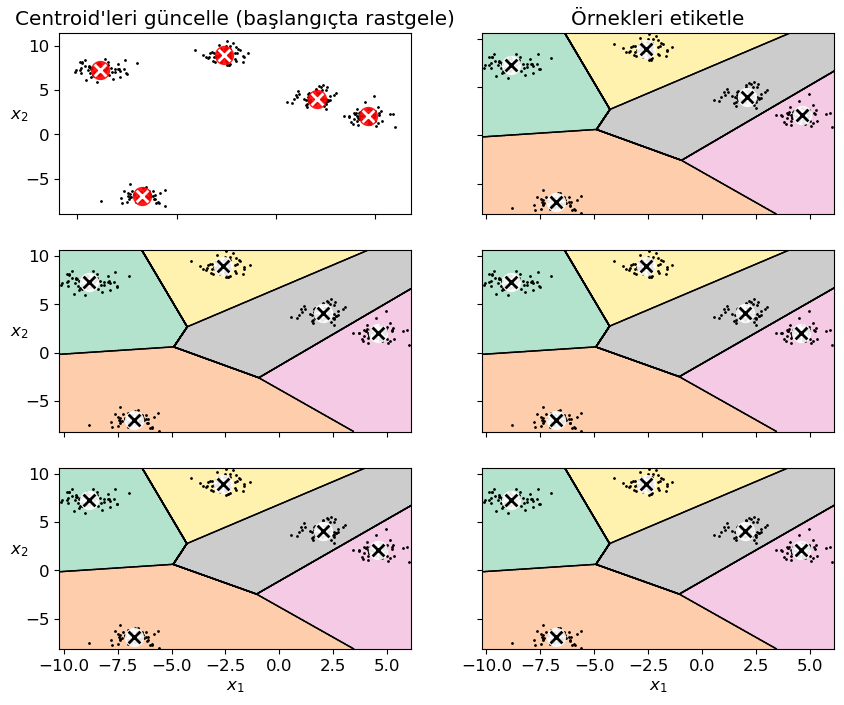

In [33]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1, random_state=18)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2, random_state=18)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3, random_state=18)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Centroid'leri güncelle (başlangıçta rastgele)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Örnekleri etiketle")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

**📌 Açıklama:**

```python
KMeans(init="random", n_init=1, max_iter=1/2/3, random_state=18)
```
- `init="random"` → Centroid'leri gerçekten rastgele seç (k-means++ yerine) — eğitim amaçlı
- `n_init=1` → Yalnızca 1 kez çalıştır
- `max_iter=1/2/3` → Her model farklı sayıda iterasyon çalışıyor
- `random_state=18` → Üçü de **aynı rastgele başlangıç noktası** kullanıyor; sadece iterasyon sayısı farklı

```python
plt.subplot(321)   # 3 satır, 2 sütun, 1. hücre
```
Sol sütun → centroid güncelleme adımı. Sağ sütun → etiketleme adımı.

```python
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False)
plot_centroids(kmeans_iter2.cluster_centers_)
```
Önceki iterasyonun karar sınırları + yeni hesaplanan centroid'leri üst üste çiz → centroid'lerin nasıl kaydığını göster.

### Rastgele Başlatma Değişkenliği

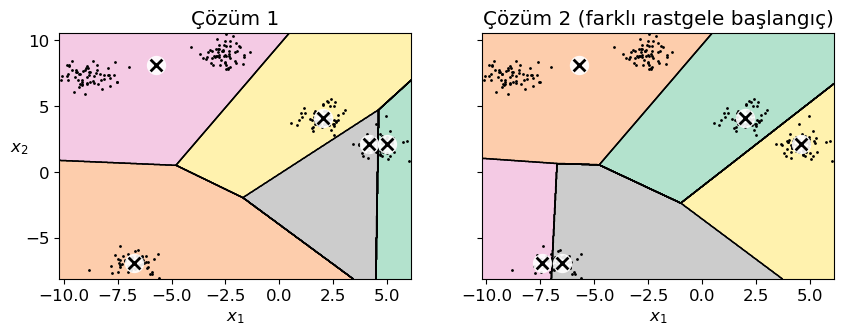

In [35]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)

kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=8)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Çözüm 1", "Çözüm 2 (farklı rastgele başlangıç)")
plt.show()

**📌 Açıklama:**

```python
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=8)
```
Her iki model de 1 kez çalışıyor fakat **farklı rastgele başlangıç** noktaları (`random_state=2` vs `8`).

Bu değişkenlik K-Means'in en büyük zayıflığını gösterir: farklı başlangıçlar farklı lokal minimumlara yakınsayabilir.

**Çözüm:** `n_init=10` veya `init='k-means++'` kullanmak.

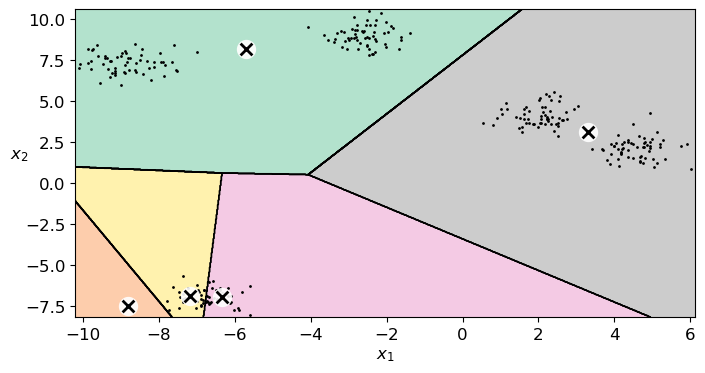

In [36]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)
kmeans.fit(X)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

**📌 Açıklama:**

```python
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
```
Shape `(5, 2)` — Veriyi görsel inceleyerek bulduğumuz 5 iyi başlangıç koordinatı.

```python
KMeans(init=good_init, ...)
```
`init` parametresine array verilince centroid'ler bu koordinatlardan başlar. Sonuç tek çalıştırmada mükemmel.

### 3.2 İnertia (Atalet) Nedir?

**İnertia**, her örnek ile en yakın küme merkezi arasındaki **kare mesafelerin toplamıdır**:

$$\text{İnertia} = \sum_{i} \| \mathbf{x}^{(i)} - \mathbf{c}^{(i)} \|^2$$

- İnertia ne kadar düşükse model o kadar iyidir
- Ancak k arttıkça inertia her zaman düşer → tek başına kullanılamaz!
- `score()` metodu negatif inertia döndürür (Scikit-Learn'ün "büyük = iyi" kuralı gereği)

### İnertia: Hesaplama ve Doğrulama

In [37]:
print("İyi başlangıçlı model inertia:  ", kmeans.inertia_)
print("Rastgele başlangıç 1 inertia:   ", kmeans_rnd_init1.inertia_)
print("Rastgele başlangıç 2 inertia:   ", kmeans_rnd_init2.inertia_)

# İnertia'yı sıfırdan hesapla ve doğrula
X_dist = kmeans.transform(X)   # Her örnek ile her centroid arası mesafe (2000 x 5)
manuel_inertia = (X_dist[np.arange(len(X_dist)), kmeans.labels_] ** 2).sum()
print("\nManuel hesaplanan inertia:", manuel_inertia)

# score() negatif inertia döndürür
print("score() sonucu (negatif):  ", kmeans.score(X))

İyi başlangıçlı model inertia:   1762.1023775752546
Rastgele başlangıç 1 inertia:    1445.9798511496087
Rastgele başlangıç 2 inertia:    1445.9807518949192

Manuel hesaplanan inertia: 1762.1023775752544
score() sonucu (negatif):   -1762.1023775752546


**📌 İnertia Manuel Hesaplama Adımları:**

```python
X_dist = kmeans.transform(X)
```
Shape `(2000, 5)` — 2000 örneğin 5 centroid'e olan mesafeleri.

```python
X_dist[np.arange(len(X_dist)), kmeans.labels_]
```
**Gelişmiş NumPy indeksleme (Fancy Indexing):**
- `np.arange(len(X_dist))` → `[0, 1, 2, ..., 1999]` — satır indeksleri
- `kmeans.labels_` → `[3, 0, 2, ..., 1]` — her örneğin atandığı küme indeksi
- Bu ikili indeks, her satırdan **yalnızca atandığı kümeye olan mesafeyi** seçer
- Sonuç: shape `(2000,)` — her örnek için 1 mesafe değeri

```python
(... ** 2).sum()
```
Tüm mesafeleri karele al ve topla → İnertia: $\sum_i \|x^{(i)} - c^{(i)}\|^2$

```python
kmeans.score(X)    # Negatif inertia — Scikit-Learn kuralı: "büyük = daha iyi"
```

### Çoklu Rastgele Başlatma (n_init=10)

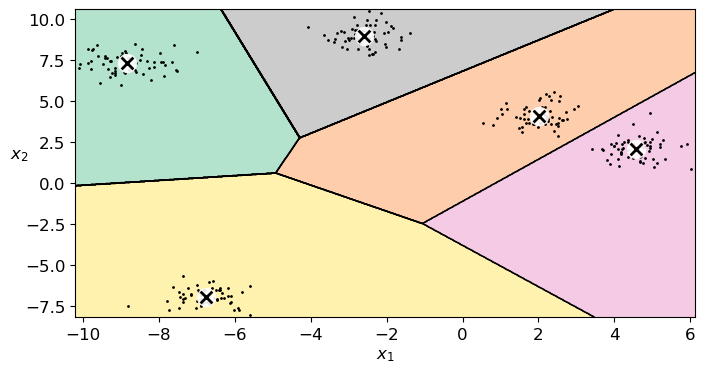

10 deneme sonrası en iyi inertia: 202.36345124966653


In [38]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10, random_state=2)
kmeans_rnd_10_inits.fit(X)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

print("10 deneme sonrası en iyi inertia:", kmeans_rnd_10_inits.inertia_)

**📌 Açıklama:**

```python
KMeans(n_clusters=5, init="random", n_init=10, random_state=2)
```
- `n_init=10` → Algoritma **10 farklı rastgele başlangıç** ile çalışır
- 10 çalışmanın en düşük inertia'sına sahip modeli saklar

**`init` ve `n_init` varsayılanları:**

| `init` | Varsayılan `n_init` |
|--------|---------------------|
| `'k-means++'` | 1 |
| `'random'` | 10 |

k-means++ başlangıçta zaten iyi bir çözüm önerir, bu yüzden tek deneme genellikle yeterli.

---

### 3.3 Merkez Başlatma Yöntemleri

#### K-Means++ (Varsayılan)

2006 yılında David Arthur ve Sergei Vassilvitskii tarafından önerilen daha akıllı bir başlatma yöntemidir.

**Temel fikir:** Merkezleri birbirinden uzak seçerek başla.

**Adımlar:**
1. İlk merkez rastgele seçilir
2. Sonraki merkez, mevcut merkezlere uzaklıkla orantılı olasılıkla seçilir (uzak olanlar daha olası)
3. k merkez seçilene kadar tekrarla

Scikit-Learn'de `init='k-means++'` (varsayılan) olarak ayarlanmıştır.

In [5]:
# Farklı başlatma yöntemlerini karşılaştır
print("🔄 Farklı K-Means Başlatma Yöntemleri:")

# Manuel iyi başlangıç noktaları
good_init = np.array([[-3, 2], [-1, 2], [0, 0], [2, 2], [3, 1]])
kmeans_good = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans_good.fit(X)

# K-means++
kmeans_plus = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans_plus.fit(X)

print(f"  Manuel iyi başlangıç - İnertia: {kmeans_good.inertia_:.2f}")
print(f"  K-Means++           - İnertia: {kmeans_plus.inertia_:.2f}")
print("\n✅ K-Means++ otomatik olarak iyi başlangıç noktaları seçiyor!")

🔄 Farklı K-Means Başlatma Yöntemleri:
  Manuel iyi başlangıç - İnertia: 369.10
  K-Means++           - İnertia: 369.10

✅ K-Means++ otomatik olarak iyi başlangıç noktaları seçiyor!


---

### 3.4 Hızlandırılmış K-Means ve Mini-Batch K-Means

#### Elkan'ın Hızlandırılmış K-Means
Charles Elkan (2003) tarafından önerilmiştir. **Üçgen eşitsizliğini** kullanarak gereksiz mesafe hesaplamalarını önler. `algorithm='elkan'` ile etkinleştirilebilir.

#### Mini-Batch K-Means
David Sculley (2010) tarafından önerilmiştir. Her iterasyonda tam veri yerine **küçük mini-batch'ler** kullanır.

**Avantajları:**
- Çok daha hızlı
- Belleğe sığmayan büyük veri setleri için uygun

**Dezavantajı:** Biraz daha yüksek inertia (daha az hassas)

###  MiniBatchKMeans Temel Kullanım

In [39]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

print("MiniBatchKMeans inertia:", minibatch_kmeans.inertia_)
print("(Normal KMeans inertia: ", kmeans.inertia_, ")")

MiniBatchKMeans inertia: 202.8305085496762
(Normal KMeans inertia:  1762.1023775752546 )


**📌 Açıklama:**

```python
MiniBatchKMeans(n_clusters=5, random_state=42)
```
Arayüz `KMeans` ile aynı, ama her iterasyonda tüm veri yerine **rastgele küçük bir batch** (varsayılan: 1024 örnek) kullanır.

**Prensip:** Her adımda küçük bir örnek grubu al → ata → centroid'leri kısmen güncelle → tekrar et.

| | KMeans | MiniBatchKMeans |
|--|--------|-----------------|
| Hız | Yavaş | Hızlı |
| Bellek | Tüm veri | Batch kadar |
| Kalite | Optimal | Yaklaşık |

In [6]:
import time

# Büyük veri seti oluştur
X_large, _ = make_blobs(n_samples=50000, centers=blob_centers,
                         cluster_std=blob_std, random_state=42)

# Standart K-Means
t0 = time.time()
kmeans_std = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans_std.fit(X_large)
t_std = time.time() - t0

# Mini-Batch K-Means
t0 = time.time()
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, n_init=10, random_state=42)
minibatch_kmeans.fit(X_large)
t_mini = time.time() - t0

print("⚡ Hız Karşılaştırması (50.000 örnek):")
print(f"  Standart K-Means     - Süre: {t_std:.3f}s | İnertia: {kmeans_std.inertia_:.0f}")
print(f"  Mini-Batch K-Means   - Süre: {t_mini:.3f}s | İnertia: {minibatch_kmeans.inertia_:.0f}")
print(f"  Hız oranı: {t_std/t_mini:.1f}x daha hızlı")

⚡ Hız Karşılaştırması (50.000 örnek):
  Standart K-Means     - Süre: 0.266s | İnertia: 9362
  Mini-Batch K-Means   - Süre: 0.092s | İnertia: 9366
  Hız oranı: 2.9x daha hızlı


### memmap ile Büyük Veri

In [40]:
from sklearn.datasets import fetch_openml

# MNIST veri setini indir (70.000 el yazısı rakam, 784 piksel)
mnist = fetch_openml('mnist_784', as_frame=False)
X_train_mnist, y_train_mnist = mnist.data[:60000], mnist.target[:60000]

# Eğitim verisini disk tabanlı bellek eşlemesine yaz
filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write',
                     shape=X_train_mnist.shape)
X_memmap[:] = X_train_mnist   # Veriyi memmap'e kopyala
X_memmap.flush()               # RAM'deki değişiklikleri diske yaz

# memmap üzerinde MiniBatchKMeans
minibatch_kmeans_mnist = MiniBatchKMeans(n_clusters=10, batch_size=10, random_state=42)
minibatch_kmeans_mnist.fit(X_memmap)

MiniBatchKMeans(batch_size=10, n_clusters=10, random_state=42)

**📌 memmap açıklaması:**

```python
np.memmap(filename, dtype='float32', mode='write', shape=X_train_mnist.shape)
```
- `memmap` → **memory-mapped file**: büyük array'i RAM'e yüklemeden disk üzerinde işle
- `dtype='float32'` → Her değer 4 byte → 60000×784×4 = ~188MB disk alanı
- `mode='write'` → Dosyayı sıfırdan yaz (overwrite)
- `shape` → Dosyanın boyutunu önceden belirle

```python
X_memmap.flush()
```
RAM'deki değişiklikleri diske yaz (senkronize et). Bunu yapmadan dosya eksik olabilir.

```python
batch_size=10
```
Her iterasyonda yalnızca 10 örnek — gösterim amaçlı küçük; gerçekte 1024+ kullanılır.

---

### 3.5 Optimal Küme Sayısını Bulmak

K-Means'te en zorlu sorun **k değerinin belirlenmesidir**. İki popüler yöntem:

#### Yöntem 1: Dirsek Yöntemi (Elbow Method)
Farklı k değerleri için inertia'yı çizeriz. Eğrideki "dirsek" noktası optimal k'ya işaret eder.

#### Yöntem 2: Silhouette Skoru
Her örnek için silhouette katsayısı hesaplanır:

$$s = \frac{b - a}{\max(a, b)}$$

- **a**: Aynı kümedeki diğer örneklere ortalama mesafe (küme içi mesafe)
- **b**: En yakın başka kümeye ortalama mesafe (kümeler arası mesafe)
- **s = +1**: Mükemmel → Kendi kümesinin içinde, diğer kümelerden uzak
- **s ≈ 0**: Sınırda → Iki küme arasında
- **s = -1**: Kötü → Yanlış kümeye atanmış olabilir

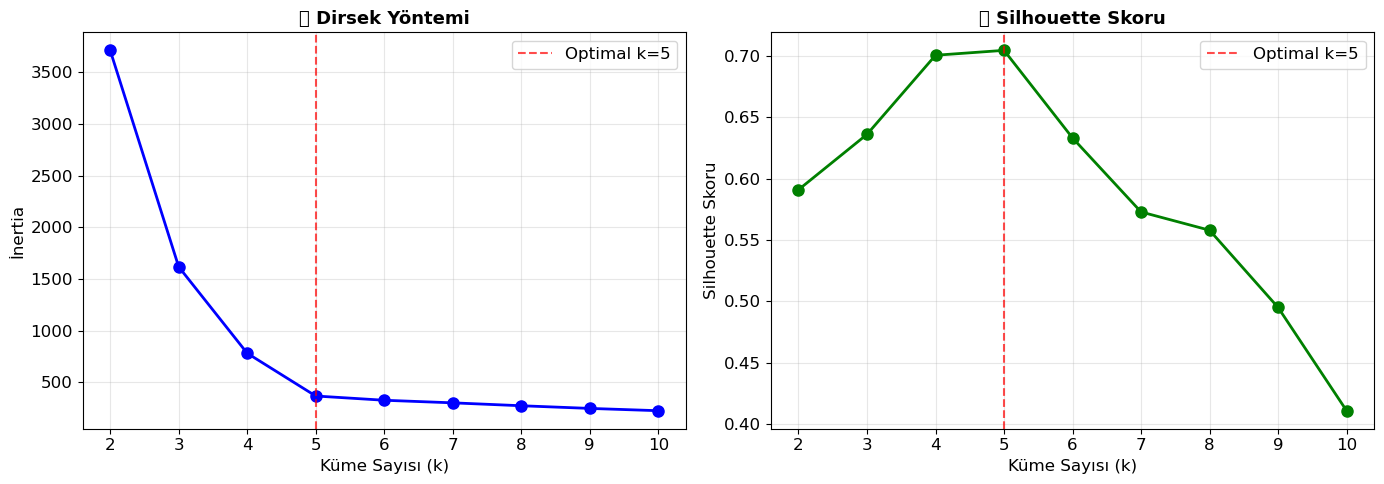

En yüksek Silhouette Skoru: k=5 için 0.7044


In [7]:
# Dirsek Yöntemi
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_k.fit(X)
    inertias.append(kmeans_k.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans_k.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# İnertia grafiği
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal k=5')
ax1.set_xlabel('Küme Sayısı (k)', fontsize=12)
ax1.set_ylabel('İnertia', fontsize=12)
ax1.set_title('📊 Dirsek Yöntemi', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Silhouette skoru grafiği
ax2.plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal k=5')
ax2.set_xlabel('Küme Sayısı (k)', fontsize=12)
ax2.set_ylabel('Silhouette Skoru', fontsize=12)
ax2.set_title('📊 Silhouette Skoru', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"En yüksek Silhouette Skoru: k={list(k_range)[np.argmax(silhouette_scores)]} için {max(silhouette_scores):.4f}")

###  Silhouette Skoru

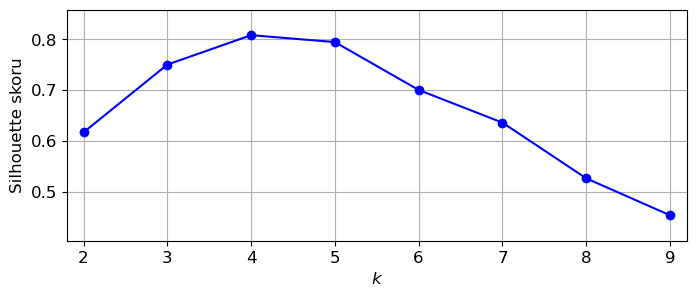

In [42]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Modelleri k=1'den k=10'a kadar eğitelim ve listeye atalım
# (silhouette_score için k en az 2 olmalıdır)
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
                for k in range(1, 10)]

# 2. k=2'den k=9'a kadar silhouette skorlarını hesaplayalım
# kmeans_per_k[1:] ifadesi k=2'den başlar (çünkü k=1 için silhouette hesaplanamaz)
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

# 3. Görselleştirme
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette skoru")
# Eksen sınırlarını verinizle uyumlu olacak şekilde ayarlayabilirsiniz
plt.axis([1.8, 9.2, min(silhouette_scores) - 0.05, max(silhouette_scores) + 0.05])
plt.grid()
plt.show()

**📌 Açıklama:**

```python
silhouette_score(X, model.labels_)
```
- Tüm örnekler üzerinde ortalama silhouette katsayısını hesaplar
- Her örnek için: $s = (b - a) / \max(a, b)$
  - $a$ = aynı kümedeki diğer örneklerle ortalama mesafe (iç uyum)
  - $b$ = en yakın komşu kümedeki örneklerle ortalama mesafe (küme ayrımı)
- Değer aralığı: -1 ile 1 arası; yüksek = iyi kümeleme

```python
for model in kmeans_per_k[1:]   # İndeks 0 = k=1, onu atla
```
k=1 ile silhouette skoru hesaplanamaz (tek küme olduğunda "en yakın komşu küme" kavramı yok).

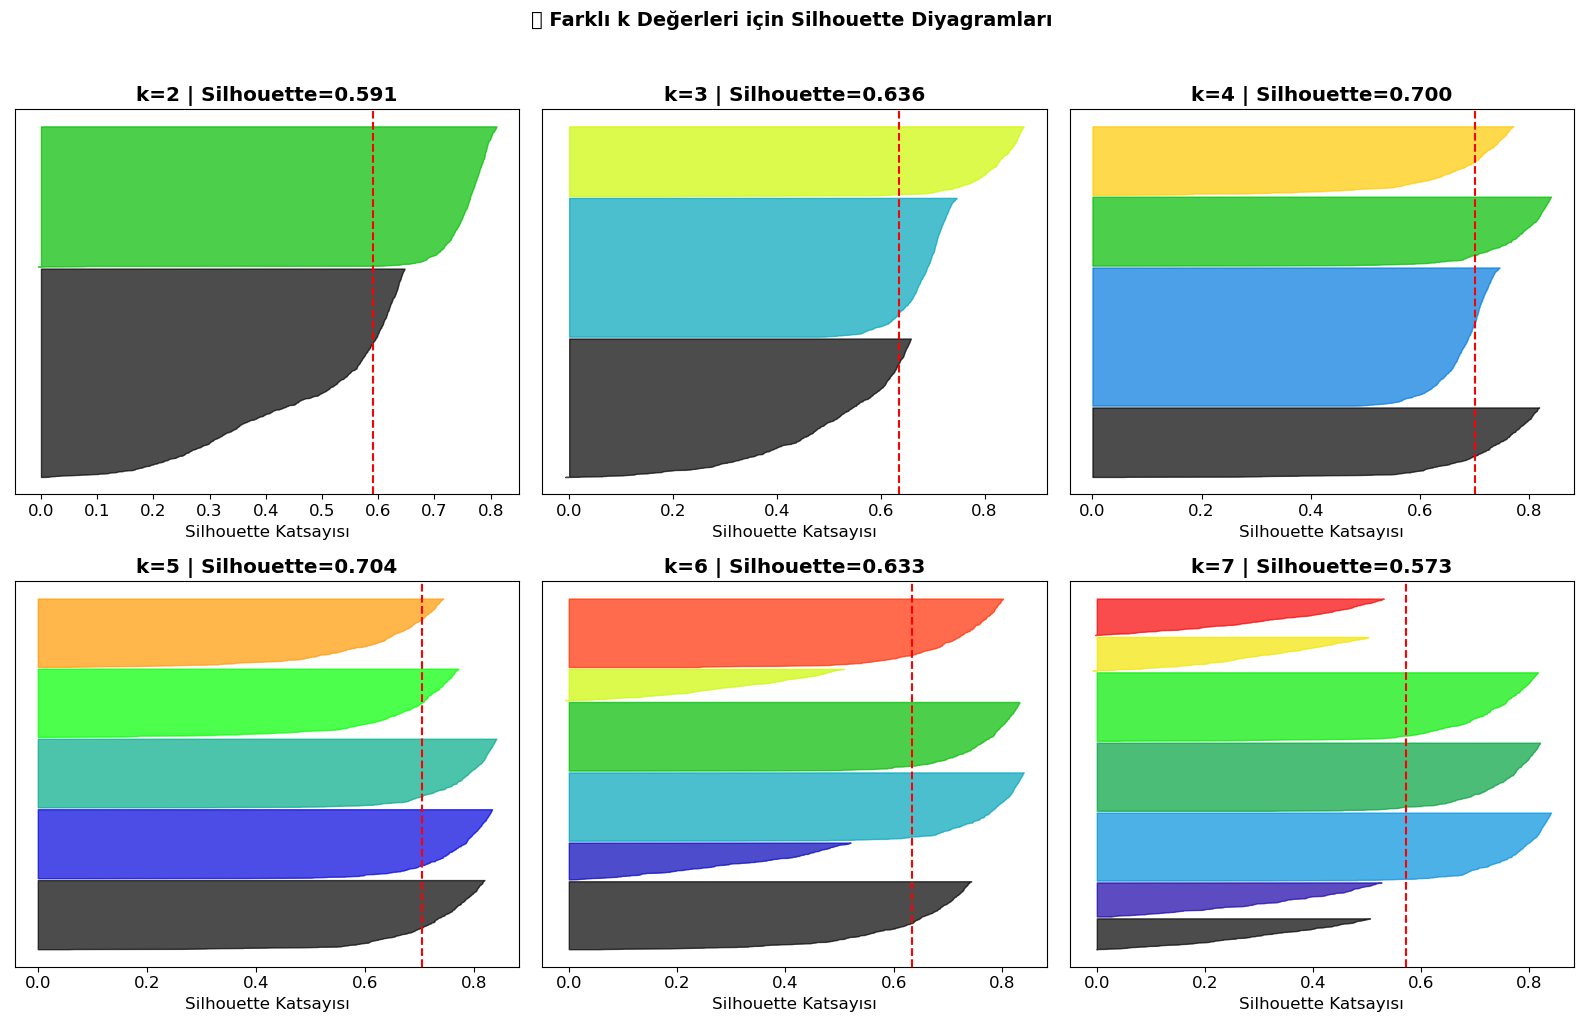

In [8]:
# Silhouette Diyagramı
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, k in enumerate([2, 3, 4, 5, 6, 7]):
    ax = axes[idx]
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)
    
    y_lower = 10
    for i in range(k):
        ith_cluster_values = sample_silhouette_values[labels == i]
        ith_cluster_values.sort()
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper + 10
    
    ax.axvline(x=score, color='red', linestyle='--')
    ax.set_title(f'k={k} | Silhouette={score:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette Katsayısı')
    ax.set_yticks([])

plt.suptitle('🔍 Farklı k Değerleri için Silhouette Diyagramları', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

### 3.6 K-Means'in Sınırları

K-Means hızlı ve ölçeklenebilir olsa da **ciddi kısıtlamaları** vardır:

1. **Rastgele başlatma sorunu:** Birden fazla çalıştırma gerektirir
2. **Küme sayısı belirtilmeli:** k önceden bilinmelidir
3. **Farklı boyutlu kümeler:** Büyük/küçük kümeler problem yaratabilir
4. **Farklı yoğunluklu kümeler:** Seyrek ve yoğun kümeler iyi ayrılamaz
5. **Küresel olmayan şekiller:** Elips veya hilal şekilli kümeler için kötü çalışır

**💡 Çözüm:** Eliptik kümeler için **Gaussian Karışım Modelleri** daha iyi sonuç verir!

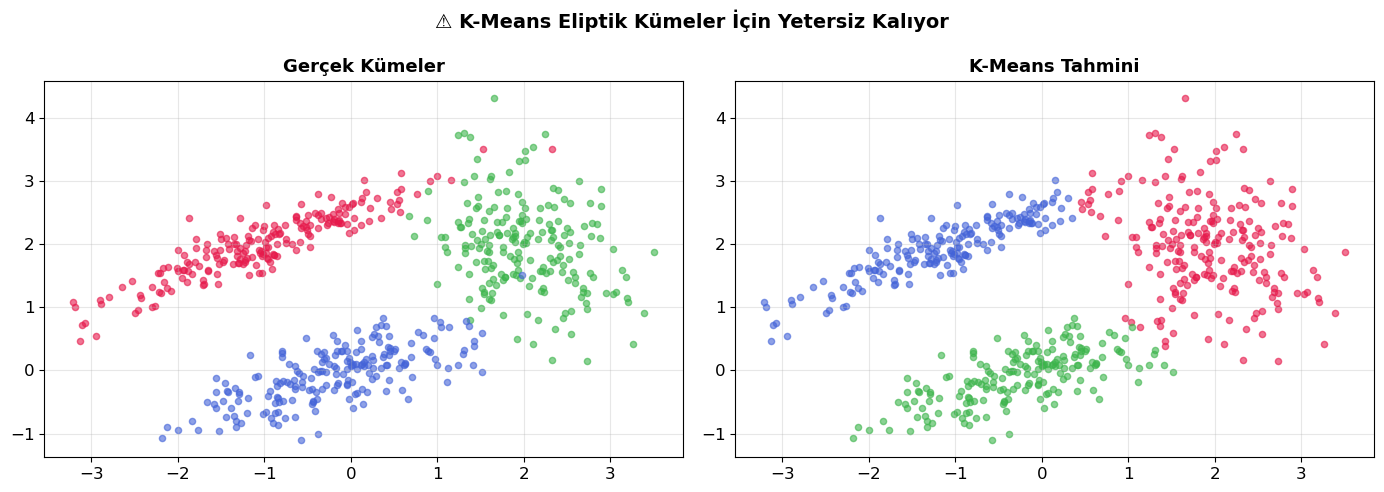

In [9]:
# K-Means'in başarısız olduğu durumu göster
np.random.seed(42)
# Eliptik kümeler oluştur
X1 = np.random.multivariate_normal([-1, 2], [[1, 0.5], [0.5, 0.3]], 200)
X2 = np.random.multivariate_normal([2, 2], [[0.3, -0.1], [-0.1, 0.5]], 200)
X3 = np.random.multivariate_normal([0, 0], [[0.8, 0.3], [0.3, 0.2]], 200)
X_ellip = np.vstack([X1, X2, X3])
y_true = np.array([0]*200 + [1]*200 + [2]*200)

kmeans_ellip = KMeans(n_clusters=3, n_init=10, random_state=42)
y_pred_ellip = kmeans_ellip.fit_predict(X_ellip)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e6194b', '#3cb44b', '#4363d8']
for i, ax, y_plot, title in [(0, ax1, y_true, 'Gerçek Kümeler'), 
                               (0, ax2, y_pred_ellip, 'K-Means Tahmini')]:
    for j in range(3):
        ax.scatter(X_ellip[y_plot==j, 0], X_ellip[y_plot==j, 1],
                   c=colors[j], alpha=0.6, s=20)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.grid(True, alpha=0.3)

plt.suptitle('⚠️ K-Means Eliptik Kümeler İçin Yetersiz Kalıyor', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 📌 Bölüm 4: K-Means'in Uygulamaları

### 4.1 Görüntü Bölütleme (Image Segmentation)

**Görüntü bölütleme** türleri:

1. **Renk Bölütleme:** Benzer renkli pikselleri aynı segmente ata → Uydu görüntüsü analizi
2. **Anlamsal Bölütleme:** Aynı nesne türündeki pikselleri grupla → Otonom araçlar
3. **Örnek Bölütleme:** Her bireysel nesneyi ayrı segment olarak işle → İleri robotik uygulamalar

K-Means ile renk bölütleme: Her piksel RGB değerleri ile temsil edilir ve kümeler bulunur.

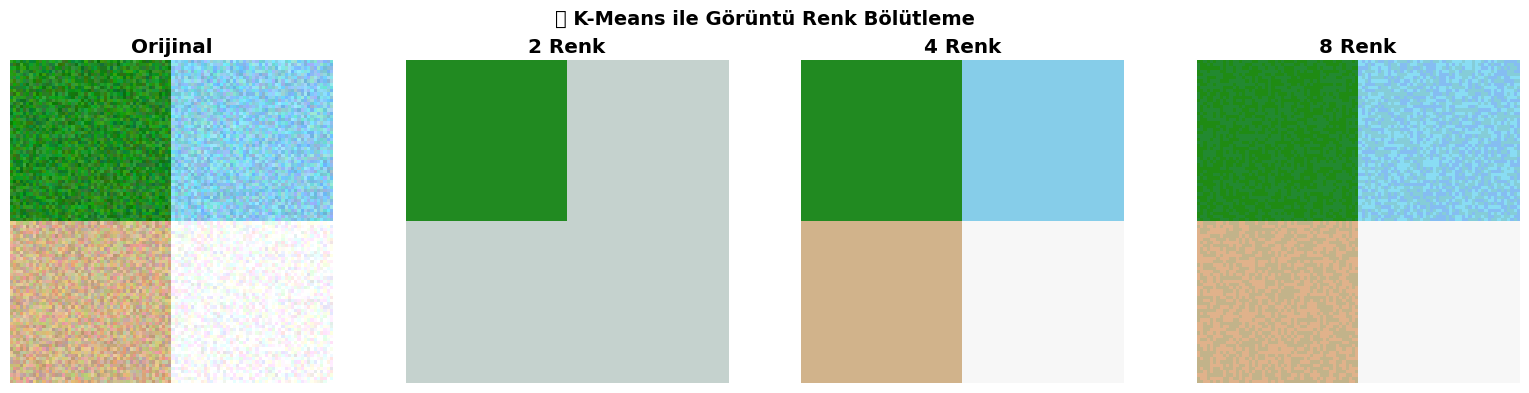

In [44]:
# Yapay görüntü oluştur ve segmentasyon uygula
np.random.seed(42)

# Renkli yapay görüntü oluştur (gerçek görüntü yerine)
image = np.zeros((100, 100, 3), dtype=np.uint8)
image[0:50, 0:50] = [34, 139, 34]    # Yeşil (orman)
image[0:50, 50:100] = [135, 206, 235]  # Mavi (gökyüzü)
image[50:100, 0:50] = [210, 180, 140] # Kahverengi (toprak)
image[50:100, 50:100] = [255, 255, 255] # Beyaz (kar)
# Gürültü ekle
noise = np.random.randint(-30, 30, image.shape)
image = np.clip(image.astype(int) + noise, 0, 255).astype(np.uint8)

# K-Means ile renk bölütleme
def segment_image(image, n_clusters):
    X_img = image.reshape(-1, 3).astype(float)
    km = KMeans(n_clusters=n_clusters, n_init=3, random_state=42)
    km.fit(X_img)
    segmented = km.cluster_centers_[km.labels_]
    return segmented.reshape(image.shape).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image)
axes[0].set_title('Orijinal', fontweight='bold')

for i, n_colors in enumerate([2, 4, 8]):
    seg = segment_image(image, n_colors)
    axes[i+1].imshow(seg)
    axes[i+1].set_title(f'{n_colors} Renk', fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.suptitle('🖼️ K-Means ile Görüntü Renk Bölütleme', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### 4.2 Yarı-Gözetimli Öğrenme için Kümeleme

**Senaryo:** Çok sayıda etiketsiz örneğiniz ve çok az etiketli örneğiniz var.

**Strateji:**
1. Eğitim setini k kümesine böl
2. Her kümeden en temsil edici örneği bul (centroid'e en yakın)
3. **Yalnızca bu örnekleri etiketle** (uzman zamanını verimli kullan!)
4. Etiketleri kümedeki diğer örneklere yay (**Label Propagation**)
5. Model eğit

Bu yöntem, **rastgele etiketlemeden çok daha iyi** sonuç verir!

In [11]:
# Digits veri setini yükle
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

# 1. Temel: 50 rastgele etiketli örnekle eğit
n_labeled = 50
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
baseline_score = log_reg.score(X_test, y_test)

# 2. Küme merkezlerine göre 50 temsil edici örnek seç
k = 50
kmeans_digits = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans_digits.fit_transform(X_train)
representative_idx = X_digits_dist.argmin(axis=0)  # Her kümeden en yakın örnek
X_representative = X_train[representative_idx]

# Manuel etiketleme simülasyonu (gerçek etiketleri kullanıyoruz)
y_representative = y_train[representative_idx]

log_reg2 = LogisticRegression(max_iter=10000, random_state=42)
log_reg2.fit(X_representative, y_representative)
representative_score = log_reg2.score(X_test, y_test)

# 3. Etiket yayılımı (Label Propagation)
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans_digits.labels_ == i] = y_representative[i]

log_reg3 = LogisticRegression(max_iter=10000, random_state=42)
log_reg3.fit(X_train, y_train_propagated)
propagated_score = log_reg3.score(X_test, y_test)

# 4. Aykırıları çıkararak yayılım
percentile_closest = 50
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans_digits.labels_]
for i in range(k):
    in_cluster = (kmeans_digits.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_pp = X_train[partially_propagated]
y_train_pp = y_train_propagated[partially_propagated]

log_reg4 = LogisticRegression(max_iter=10000, random_state=42)
log_reg4.fit(X_train_pp, y_train_pp)
partial_prop_score = log_reg4.score(X_test, y_test)

# Tam etiketli veri ile karşılaştırma
log_reg_full = LogisticRegression(max_iter=10000, random_state=42)
log_reg_full.fit(X_train, y_train)
full_score = log_reg_full.score(X_test, y_test)

print("📊 Yarı-Gözetimli Öğrenme - Doğruluk Karşılaştırması:")
print(f"  1️⃣  Tam etiketli (~1400 örnek)    : %{full_score*100:.1f}")
print(f"  2️⃣  50 rastgele etiketli örnek    : %{baseline_score*100:.1f}")
print(f"  3️⃣  50 temsil edici örnek (akıllı) : %{representative_score*100:.1f}  ← Daha iyi!")
print(f"  4️⃣  Etiket yayılımı               : %{propagated_score*100:.1f}  ← Çok daha iyi!")
print(f"  5️⃣  Kısmi yayılım (aykırı çıkar)  : %{partial_prop_score*100:.1f}  ← En iyi!")
print(f"\n💡 Sadece 50 etiketle tam verinin yaklaşık ~%{partial_prop_score/full_score*100:.0f}'ine ulaşıldı!")

📊 Yarı-Gözetimli Öğrenme - Doğruluk Karşılaştırması:
  1️⃣  Tam etiketli (~1400 örnek)    : %90.9
  2️⃣  50 rastgele etiketli örnek    : %75.8
  3️⃣  50 temsil edici örnek (akıllı) : %83.9  ← Daha iyi!
  4️⃣  Etiket yayılımı               : %85.9  ← Çok daha iyi!
  5️⃣  Kısmi yayılım (aykırı çıkar)  : %85.9  ← En iyi!

💡 Sadece 50 etiketle tam verinin yaklaşık ~%94'ine ulaşıldı!


### Temsil Edici Örneklerin Seçimi

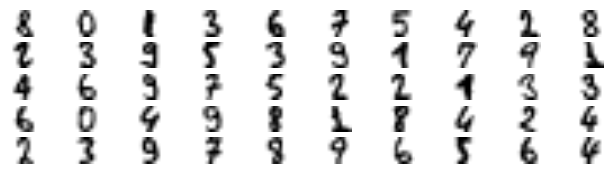

In [45]:
k = 50
kmeans_dig = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans_dig.fit_transform(X_train)     # (1400, 50) mesafe matrisi
representative_digit_idx = X_digits_dist.argmin(axis=0)  # Her kümeden en yakın örnek
X_representative_digits = X_train[representative_digit_idx]

# Temsil edici örnekleri görselleştir
plt.figure(figsize=(8, 2))
for index, X_repr_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_repr_digit.reshape(8, 8), cmap="binary", interpolation="bilinear")
    plt.axis('off')
plt.show()

**📌 Satır satır açıklama:**

```python
X_digits_dist = kmeans_dig.fit_transform(X_train)
```
`fit_transform()` = `fit()` + `transform()` tek adımda. Sonuç shape: `(1400, 50)` — 1400 örnek × 50 kümeye olan mesafeler.

```python
representative_digit_idx = X_digits_dist.argmin(axis=0)
```
- `axis=0` → Her sütun boyunca (her küme için) minimum değerin **satır indeksini** bul
- Sonuç: shape `(50,)` — her kümeden en yakın örneğin indeksi
- Bu örnekler = centroid'e en yakın → en "tipik" örnekler

```python
plt.subplot(k // 10, 10, index + 1)
```
5 satır × 10 sütunluk ızgara (50 görüntü için).

```python
X_repr_digit.reshape(8, 8)    # Düzleştirilmiş 64 piksel → 8×8 görüntü
cmap="binary"                  # Açık=0 (beyaz), Koyu=255 (siyah)
interpolation="bilinear"       # Pikseller arası yumuşak geçiş
```

###  Etiket Yayılımı (Label Propagation)

In [46]:
# Temsil edici örneklerin manuel etiketleri (insan tarafından bakılarak)
y_representative_digits = np.array([
    8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4,
])

# Temsil edici örneklerle eğit
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
print(f"50 temsil edici örnekle:        {log_reg.score(X_test, y_test):.4f}")

# Etiket yayılımı: Aynı kümedeki tüm örneklere etiketi yay
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans_dig.labels_ == i] = y_representative_digits[i]

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)
print(f"Etiket yayılımı sonrası:        {log_reg.score(X_test, y_test):.4f}")

50 temsil edici örnekle:        0.8338
Etiket yayılımı sonrası:        0.8715


**📌 Etiket yayılımı detayı:**

```python
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
```
1400 elemanlı boş array oluştur.

```python
for i in range(k):
    y_train_propagated[kmeans_dig.labels_ == i] = y_representative_digits[i]
```
- `kmeans_dig.labels_ == i` → i. kümede olan tüm örnekler (boolean mask)
- Bu örneklere `y_representative_digits[i]` etiketini at

**Varsayım:** Aynı kümedeki tüm örnekler temsil edici örnek ile aynı sınıfa ait.

In [47]:
# Kısmi yayılım: En yakın %50'yi tut, uzakları at
percentile_closest = 50

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans_dig.labels_]
for i in range(k):
    in_cluster = (kmeans_dig.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)  # Medyan
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1    # Uzakları işaretle

partially_propagated = (X_cluster_dist != -1)         # Yakın olanları seç
X_train_pp = X_train[partially_propagated]
y_train_pp = y_train_propagated[partially_propagated]

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_pp, y_train_pp)
print(f"Kısmi yayılım sonrası:          {log_reg.score(X_test, y_test):.4f}")

dogruluk = (y_train_pp == y_train[partially_propagated]).mean()
print(f"Yayılan etiketlerin gerçek doğruluğu: {dogruluk:.4f}")

Kısmi yayılım sonrası:          0.8841
Yayılan etiketlerin gerçek doğruluğu: 0.9888


**📌 Kısmi Yayılım Algoritması:**

```python
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans_dig.labels_]
```
Her örnek için **yalnızca atandığı kümeye olan mesafe** → shape `(1400,)` (Fancy indexing)

```python
cutoff_distance = np.percentile(cluster_dist, 50)  # Medyan = 50. persentil
```

```python
above_cutoff = (X_cluster_dist > cutoff_distance)
X_cluster_dist[in_cluster & above_cutoff] = -1    # Hem o kümede hem uzak → işaretle
```

**Mantık:** Centroid'e yakın örnekler daha güvenilir → aykırıları çıkararak etiket kalitesini artır.

### 🧠 Aktif Öğrenme (Active Learning)

Yarı-gözetimli öğrenmenin bir adım ötesi olan **aktif öğrenme**, modelin hangi örneklerin etiketlenmesini istediğini insan uzmana sorduğu bir süreçtir.

**Belirsizlik Örneklemesi (Uncertainty Sampling) Adımları:**
1. Etiketli örneklerle modeli eğit
2. Modelin en az emin olduğu örnekleri bul
3. Bu örnekleri uzmana etiketle
4. İyileşme durduğunda dur

**Scikit-Learn'de Etiket Yayılımı:**
- `LabelSpreading` ve `LabelPropagation` (sklearn.semi_supervised)
- `SelfTrainingClassifier` — kendi kendine tahmin edip etiket ekler

---

## 📌 Bölüm 5: DBSCAN Algoritması

### DBSCAN Nedir?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise — Gürültüye Dayanıklı Yoğunluk Tabanlı Kümeleme), kümeleri **yüksek yoğunluklu sürekli bölgeler** olarak tanımlar.

### Temel Kavramlar:

| Kavram | Açıklama |
|--------|----------|
| **ε (epsilon)** | Komşuluk yarıçapı |
| **min_samples** | Çekirdek olmak için gereken minimum komşu sayısı |
| **Çekirdek Örnek** | ε-komşuluğunda en az min_samples örnek olan nokta |
| **Sınır Örneği** | Çekirdek değil ama bir çekirdeğin komşuluğunda |
| **Anomali** | Ne çekirdek ne de sınır örneği → **Gürültü** (-1 etiketi) |

### Algoritmanın Çalışması:
1. Her örnek için ε-komşuluğundaki örnek sayısını say
2. `min_samples`'tan fazla komşusu olan örnekler → **çekirdek örnek**
3. Bir çekirdeğin komşuluğundaki tüm örnekler aynı kümeye ait
4. Zincirleme komşuluklar tek bir büyük küme oluşturur
5. Çekirdek veya komşu olmayan örnekler → **anomali**

### DBSCAN Temel Kullanım

In [48]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

print("İlk 10 etiket (-1=anomali):", dbscan.labels_[:10])
print("İlk 10 çekirdek indeks:    ", dbscan.core_sample_indices_[:10])
print("Çekirdek örnekler şekli:   ", dbscan.components_.shape)

İlk 10 etiket (-1=anomali): [ 0  2 -1 -1  1  0  0  0  2  5]
İlk 10 çekirdek indeks:     [ 0  4  5  6  7  8 10 11 12 13]
Çekirdek örnekler şekli:    (808, 2)


**📌 Açıklama:**

```python
DBSCAN(eps=0.05, min_samples=5)
```
- `eps=0.05` → ε-komşuluk yarıçapı: bir örneğin 0.05 birim dairesindeki noktalar komşusu sayılır
- `min_samples=5` → Çekirdek örnek olmak için en az 5 komşu gerekir

```python
dbscan.labels_     # -1 = anomali/gürültü
dbscan.core_sample_indices_   # Çekirdek örneklerin X içindeki indeksleri
dbscan.components_            # Çekirdek örneklerin koordinatları
```

🔍 DBSCAN Sonuçları:
  Bulunan küme sayısı: 2
  Anomali sayısı: 0
  Çekirdek örnek sayısı: 1000


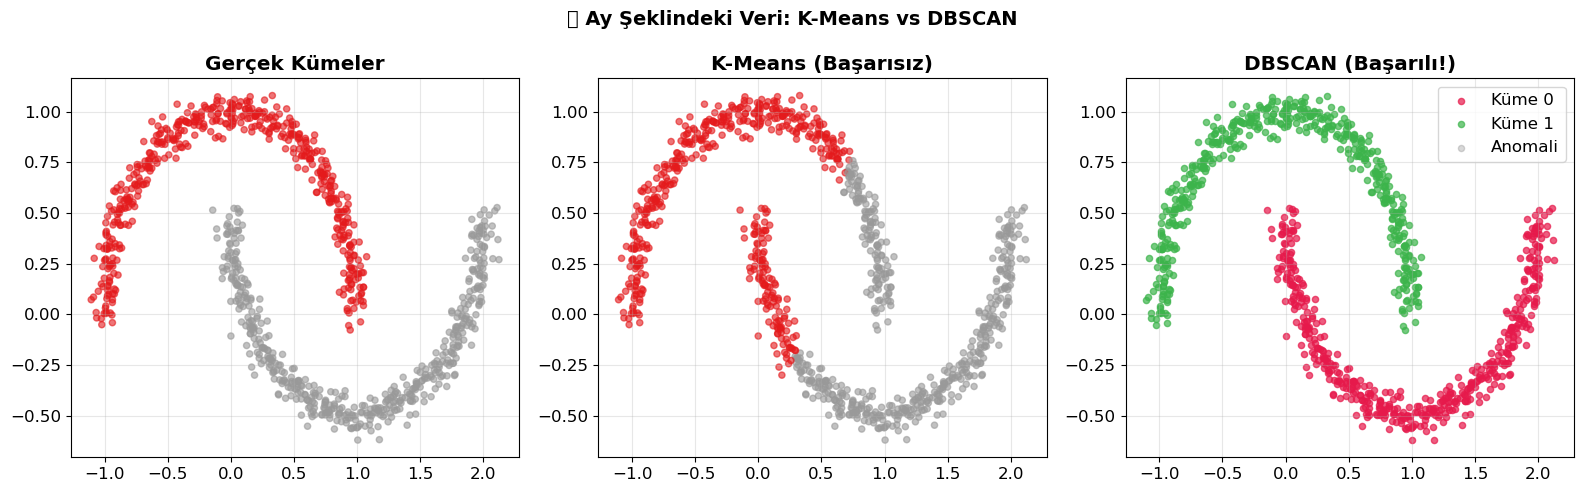

In [12]:
# Ay şeklinde veri seti oluştur (K-Means için zor)
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

# DBSCAN ile kümeleme
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X_moons)

print("🔍 DBSCAN Sonuçları:")
print(f"  Bulunan küme sayısı: {len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)}")
print(f"  Anomali sayısı: {(dbscan.labels_ == -1).sum()}")
print(f"  Çekirdek örnek sayısı: {len(dbscan.core_sample_indices_)}")

# K-Means ile karşılaştır
kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
y_pred_moons = kmeans_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gerçek etiketler
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, 
                cmap='Set1', alpha=0.6, s=20)
axes[0].set_title('Gerçek Kümeler', fontweight='bold')

# K-Means
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_pred_moons, 
                cmap='Set1', alpha=0.6, s=20)
axes[1].set_title('K-Means (Başarısız)', fontweight='bold')

# DBSCAN
colors_dbscan = {0: '#e6194b', 1: '#3cb44b', -1: 'gray'}
for label, color in colors_dbscan.items():
    mask = dbscan.labels_ == label
    alpha = 0.3 if label == -1 else 0.7
    label_name = f'Küme {label}' if label >= 0 else 'Anomali'
    axes[2].scatter(X_moons[mask, 0], X_moons[mask, 1], 
                    c=color, alpha=alpha, s=20, label=label_name)
axes[2].set_title('DBSCAN (Başarılı!)', fontweight='bold')
axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('🌙 Ay Şeklindeki Veri: K-Means vs DBSCAN', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# DBSCAN ile KNN kullanarak yeni örnekleri tahmin etme
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, 
        dbscan.labels_[dbscan.core_sample_indices_])

X_new_moons = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
y_dist, y_pred_idx = knn.kneighbors(X_new_moons, n_neighbors=1)
y_pred_new = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred_new[y_dist > 0.2] = -1  # Uzak olanları anomali say

print("🔮 DBSCAN + KNN ile Yeni Örnek Tahmini:")
print(f"  Yeni noktalar: {X_new_moons}")
print(f"  Tahminler: {y_pred_new.ravel()}")
print("  (-1 = Anomali, 0 veya 1 = Küme)")

🔮 DBSCAN + KNN ile Yeni Örnek Tahmini:
  Yeni noktalar: [[-0.5  0. ]
 [ 0.   0.5]
 [ 1.  -0.1]
 [ 2.   1. ]]
  Tahminler: [-1  0  1 -1]
  (-1 = Anomali, 0 veya 1 = Küme)


### DBSCAN'ın Güçlü ve Zayıf Yönleri:

**✅ Güçlü Yönler:**
- Küme sayısını önceden belirtmeye gerek yok
- Rastgele şekilli kümeler bulabilir
- Aykırı değerlere (anomalilere) karşı dayanıklı
- Yalnızca 2 hiperparametre: eps ve min_samples

**❌ Zayıf Yönler:**
- Farklı yoğunluktaki kümeler sorun çıkarabilir
- Hesaplama karmaşıklığı O(m²n) — büyük veri setleri için yavaş

**💡 İpucu:** Değişen yoğunluktaki kümeler için **HDBSCAN** (`sklearn.cluster.HDBSCAN`) daha iyi sonuç verir!

---

## 📌 Bölüm 6: Diğer Kümeleme Algoritmaları

| Algoritma | Avantaj | Dezavantaj |
|-----------|---------|------------|
| **Aglomeratif Kümeleme** | Her şekli yakalayabilir, dendogram üretir | Bağlantı matrisi olmadan büyük veri için yavaş |
| **BIRCH** | Çok büyük veri setleri için tasarlandı | Çok boyutlu veri için zayıf (>20 özellik) |
| **Mean-Shift** | Küme sayısı gerekmez, yerel yoğunluğa dayalı | O(m²n) karmaşıklığı, büyük veri için uygunsuz |
| **Affinity Propagation** | Küme sayısı gerekmez, farklı boyutlu kümeler | O(m²) karmaşıklığı |
| **Spectral Clustering** | Karmaşık yapıları yakalar | Büyük veri için ölçeklenmez |

### Spectral Clustering

In [49]:
from sklearn.cluster import SpectralClustering

sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)
print("Benzerlik matrisi örneği (gamma=100, 3x3):")
print(sc1.affinity_matrix_.round(2)[:3, :3])

sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

Benzerlik matrisi örneği (gamma=100, 3x3):
[[1.  0.  0. ]
 [0.  1.  0.3]
 [0.  0.3 1. ]]


SpectralClustering(gamma=1, n_clusters=2, random_state=42)

**📌 Açıklama:**

```python
SpectralClustering(n_clusters=2, gamma=100, ...)
```
- `gamma` → RBF çekirdeği: $K(x, z) = e^{-\gamma ||x-z||^2}$
- **Yüksek gamma (100):** Sadece çok yakın komşular yüksek benzerliğe sahip
- **Düşük gamma (1):** Uzak örnekler de biraz benzer sayılır

```python
sc1.affinity_matrix_
```
Shape `(1000, 1000)` — Tüm örnekler arası benzerlik matrisi. Spectral bu matrisin özvektörlerini kullanır.

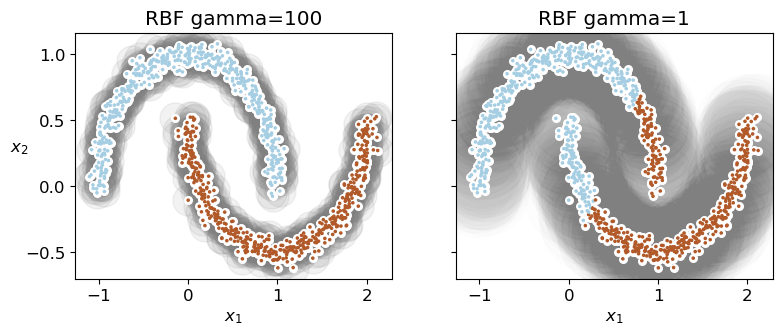

In [50]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True, show_ylabels=True):
    # 3 katmanlı görsel: gri halka + beyaz iç + renkli nokta
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")

plt.figure(figsize=(9, 3.2))
plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)
plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)
plt.show()

**📌 3 Katmanlı Görsel Tekniği:**

1. `s=size, c='gray', alpha=alpha` → Büyük şeffaf gri daireler (benzerlik bölgesini gösterir)
2. `s=30, c='w'` → Küçük beyaz daireler (gri'nin ortasını beyaza çevirir → halka efekti)
3. `s=10, c=sc.labels_` → Küçük renkli noktalar (küme etiketi)

Bu teknik gamma parametresinin etkisini görsel olarak gösterir.

### Agglomerative Clustering

In [51]:
from sklearn.cluster import AgglomerativeClustering

X_simple = np.array([0, 2, 5, 8.5]).reshape(-1, 1)
agg = AgglomerativeClustering(linkage="complete").fit(X_simple)

# Öğrenilmiş parametreleri listele (alt çizgi ile bitenler)
def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]

print("Öğrenilmiş parametreler:", learned_parameters(agg))
print("\nBirleşme ağacı (children_):")
print(agg.children_)

Öğrenilmiş parametreler: ['children_', 'labels_', 'n_clusters_', 'n_connected_components_', 'n_features_in_', 'n_leaves_']

Birleşme ağacı (children_):
[[0 1]
 [2 3]
 [4 5]]


**📌 Açıklama:**

```python
AgglomerativeClustering(linkage="complete")
```
- `linkage="complete"` → İki küme arası mesafe = en uzak iki nokta (tam bağlantı)
- Alternatifler: `"single"` (en yakın), `"average"`, `"ward"` (varyans minimizasyonu)

```python
def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]
```
Scikit-Learn kuralı: Eğitimden öğrenilen parametreler alt çizgi (`_`) ile biter. Bu fonksiyon modellenmiş tüm parametreleri listeler.

```python
agg.children_
```
Birleşme ağacı: `[[0, 1], [2, 3], ...]` — Hangi iki küme birleşti.

---

## 📌 Bölüm 7: Gaussian Karışım Modelleri (GMM)

### GMM Nedir?

**Gaussian Karışım Modeli (GMM)**, örneklerin birkaç Gaussian (Normal) dağılımın karışımından üretildiğini varsayan olasılıksal bir modeldir.

**Oluşum Süreci:**
1. Her örnek için rastgele bir küme seçilir (ağırlık ϕ ile)
2. Örnek, o kümenin Gaussian dağılımından örneklenir (μ ortalama, Σ kovaryans)

**K-Means vs GMM:**
- K-Means: Yalnızca merkez öğrenir, küre şeklini varsayar
- **GMM: Merkez + boyut + şekil + yön + ağırlıkları öğrenir!**

### Beklenti-Maksimizasyon (EM) Algoritması

GMM **EM algoritması** ile eğitilir:
- **E adımı (Beklenti):** Her örneğin her kümeye ait olma olasılığı tahmin edilir (sorumluluklar/responsibilities)
- **M adımı (Maksimizasyon):** Küme parametreleri, sorumlulukla ağırlıklandırılmış örneklerle güncellenir

**Uyarı:** EM de lokal minimuma takılabilir → `n_init` yüksek tutulmalıdır!

In [14]:
# GMM örneği - eliptik kümelerle
np.random.seed(42)
X1 = np.random.multivariate_normal([-1, 2], [[1, 0.5], [0.5, 0.3]], 500)
X2 = np.random.multivariate_normal([3, 1], [[1, -0.3], [-0.3, 0.5]], 250)
X3 = np.random.multivariate_normal([0, -1], [[0.5, 0.3], [0.3, 0.8]], 500)
X_gmm = np.vstack([X1, X2, X3])

# GMM eğit
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X_gmm)

print("📊 GMM - Tahmin Edilen Parametreler:")
print(f"  Küme ağırlıkları (φ): {gm.weights_.round(3)}")
print(f"  Gerçek ağırlıklar  : [0.4, 0.2, 0.4]")
print(f"\n  Yakınsadı mı? {gm.converged_}")
print(f"  İterasyon sayısı: {gm.n_iter_}")
print(f"\n  Küme ortalamaları:\n{gm.means_.round(2)}")

📊 GMM - Tahmin Edilen Parametreler:
  Küme ağırlıkları (φ): [0.208 0.393 0.399]
  Gerçek ağırlıklar  : [0.4, 0.2, 0.4]

  Yakınsadı mı? True
  İterasyon sayısı: 3

  Küme ortalamaları:
[[ 2.8   1.11]
 [-0.02 -0.98]
 [-1.01  2.  ]]


**📌 GMM Parametreleri:**

```python
GaussianMixture(n_components=3, n_init=10, random_state=42)
```
- `n_components=3` → 3 Gaussian bileşeni (küme)
- `n_init=10` → EM algoritması 10 farklı başlangıçla çalışır; en iyi log-likelihood seçilir

| Öznitelik | Açıklama | Shape |
|-----------|----------|-------|
| `weights_` | Küme ağırlıkları ϕ (toplamı 1) | `(3,)` |
| `means_` | Küme ortalamaları μ | `(3, 2)` |
| `covariances_` | Kovaryans matrisleri Σ | `(3, 2, 2)` |
| `converged_` | EM yakınsadı mı? | `bool` |
| `n_iter_` | İterasyon sayısı | `int` |

### Tahmin, Örnekleme ve Yoğunluk

In [52]:
# Sert kümeleme
print("Sert kümeleme (ilk 10):", gm.predict(X)[:10])

# Yumuşak kümeleme (olasılıklar)
print("\nYumuşak kümeleme (ilk 3):")
print(gm.predict_proba(X).round(3)[:3])

# Yeni örnekler üret
X_new, y_new = gm.sample(6)
print("\nÜretilen 6 yeni örnek:")
print(X_new.round(2))
print("Küme etiketleri:", y_new)

# Log-PDF değerleri
print("\nLog-PDF skorları (ilk 5):", gm.score_samples(X).round(2)[:5])

Sert kümeleme (ilk 10): [1 1 1 1 1 1 1 1 1 1]

Yumuşak kümeleme (ilk 3):
[[0.007 0.993 0.   ]
 [0.003 0.997 0.   ]
 [0.003 0.997 0.   ]]

Üretilen 6 yeni örnek:
[[ 2.55  2.3 ]
 [ 0.2  -0.87]
 [-1.21 -1.93]
 [-0.01 -0.45]
 [ 0.43 -0.77]
 [-1.07  1.54]]
Küme etiketleri: [0 1 1 1 1 2]

Log-PDF skorları (ilk 5): [-3.91 -3.12 -2.98 -2.36 -6.51]


**📌 Metodların açıklaması:**

```python
gm.predict(X)
```
Her örneği en yüksek sorumluluğa sahip kümeye ata → sert kümeleme.

```python
gm.predict_proba(X)
```
Her örnek için her kümeye ait olma olasılığı (sorumluluk = responsibility). Shape `(n, 3)`, her satır toplamı 1.

```python
X_new, y_new = gm.sample(6)
```
GMM **üretici bir modeldir** — gerçek veriyle aynı dağılımdan yeni örnekler üretebilir! Bu diğer kümeleme algoritmalarından büyük fark.

```python
gm.score_samples(X)
```
Her örneğin **log-PDF** değeri. Yüksek skor = yüksek yoğunluk = "normal" bölge.

In [53]:
# PDF'in integralinin 1 olduğunu doğrula
resolution = 100
grid = np.arange(-10, 10, 1 / resolution)
xx, yy = np.meshgrid(grid, grid)
X_full = np.vstack([xx.ravel(), yy.ravel()]).T

pdf = np.exp(gm.score_samples(X_full))         # log-PDF → PDF
pdf_probas = pdf * (1 / resolution) ** 2        # Her kare için olasılık
print(f"PDF integrali ≈ {pdf_probas.sum():.4f} (1'e yakın olmalı)")

PDF integrali ≈ 1.0000 (1'e yakın olmalı)


**📌 PDF Doğrulama:**

```python
pdf = np.exp(gm.score_samples(X_full))
```
Log-PDF'ten PDF'e dönüş: $f(x) = e^{\log f(x)}$

```python
pdf_probas = pdf * (1 / resolution) ** 2
```
Her küçük kare için olasılık: $\text{pdf değeri} \times \text{kare alanı}$ = $f(x) \times 0.01^2$

Bu, 2D sayısal integrasyonun (Riemann toplamı) özüdür.

###  GMM Görselleştirme Fonksiyonu

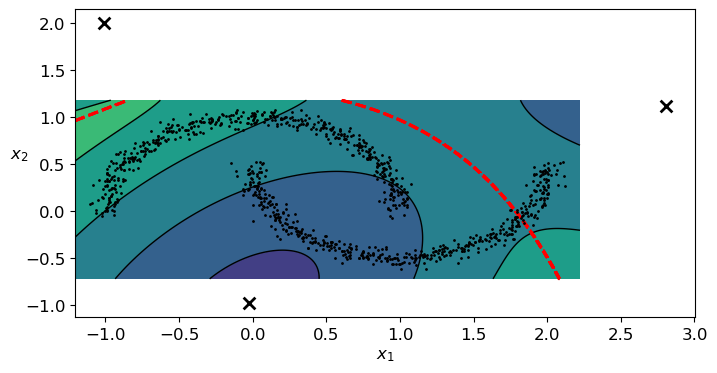

In [54]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])  # Negatif log-PDF
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12), linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_gaussian_mixture(gm, X)
plt.show()

**📌 Kritik noktalar:**

```python
Z = -clusterer.score_samples(...)
```
`score_samples()` log-PDF döndürür → **negatife çevirerek** "negatif log-yoğunluk" elde ediyoruz. Düşük yoğunluk = büyük değer = açık renk.

```python
norm=LogNorm(vmin=1.0, vmax=30.0)
levels=np.logspace(0, 2, 12)
```
- `LogNorm` → Renk skalası logaritmik (geniş yoğunluk aralıkları için)
- `logspace(0, 2, 12)` → 12 kontur seviyesi: $10^0=1$, $10^{0.18}$, ..., $10^2=100$

```python
plt.contour(xx, yy, Z_pred, colors='r', linestyles='dashed')   # Karar sınırları
```
Küme sınırları kırmızı kesik çizgilerle ayrı bir katmanda.

In [15]:
# Sert ve yumuşak kümeleme
y_hard = gm.predict(X_gmm)                    # Sert kümeleme
y_soft = gm.predict_proba(X_gmm).round(3)     # Yumuşak kümeleme (olasılıklar)

print("🔮 GMM Tahminleri:")
print(f"  Sert kümeleme (ilk 5): {y_hard[:5]}")
print(f"  Yumuşak kümeleme olasılıkları (ilk 3):\n{y_soft[:3]}")

# Yeni örnek üret (GMM üretici bir model!)
X_new_gen, y_new_gen = gm.sample(6)
print(f"\n🎲 GMM'den Üretilen Yeni Örnekler:")
print(f"  Örnekler:\n{X_new_gen.round(2)}")
print(f"  Küme etiketleri: {y_new_gen}")

🔮 GMM Tahminleri:
  Sert kümeleme (ilk 5): [2 2 2 2 2]
  Yumuşak kümeleme olasılıkları (ilk 3):
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

🎲 GMM'den Üretilen Yeni Örnekler:
  Örnekler:
[[ 2.55  2.3 ]
 [ 0.2  -0.87]
 [-1.21 -1.93]
 [-0.01 -0.45]
 [ 0.43 -0.77]
 [-1.07  1.54]]
  Küme etiketleri: [0 1 1 1 1 2]


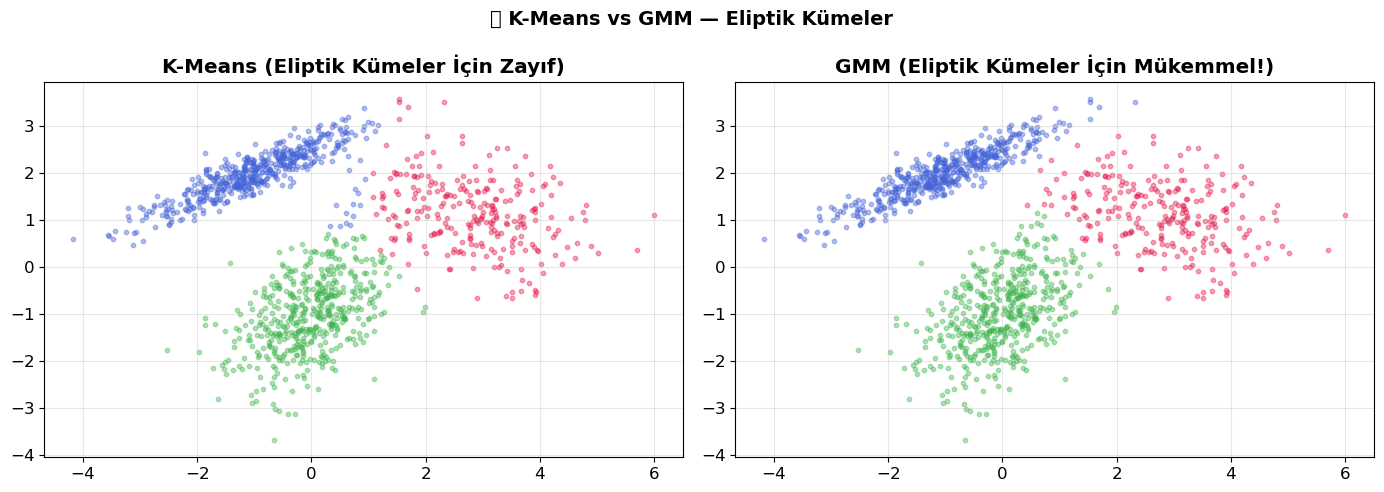

In [16]:
# GMM'nin eliptik kümeler üzerindeki başarısını göster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
km_gmm = KMeans(n_clusters=3, n_init=10, random_state=42)
y_km_gmm = km_gmm.fit_predict(X_gmm)

colors = ['#e6194b', '#3cb44b', '#4363d8']
for i in range(3):
    axes[0].scatter(X_gmm[y_km_gmm==i, 0], X_gmm[y_km_gmm==i, 1],
                    c=colors[i], alpha=0.4, s=10)
axes[0].set_title('K-Means (Eliptik Kümeler İçin Zayıf)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

for i in range(3):
    axes[1].scatter(X_gmm[y_hard==i, 0], X_gmm[y_hard==i, 1],
                    c=colors[i], alpha=0.4, s=10)
axes[1].set_title('GMM (Eliptik Kümeler İçin Mükemmel!)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('📊 K-Means vs GMM — Eliptik Kümeler', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### 7.1 Kovaryans Tipi (covariance_type)

GMM'de kümelerin şekillerini sınırlandırmak için `covariance_type` parametresi kullanılır:

| Değer | Açıklama | Karmaşıklık |
|-------|----------|-------------|
| `"full"` | Her küme herhangi bir şekil alabilir (varsayılan) | O(kmn² + kn³) |
| `"tied"` | Tüm kümeler aynı şekle sahip | O(kmn² + kn³) |
| `"diag"` | Eksenlerle hizalı elipsler | O(kmn) |
| `"spherical"` | Küresel kümeler, farklı boyutlarda | O(kmn) |

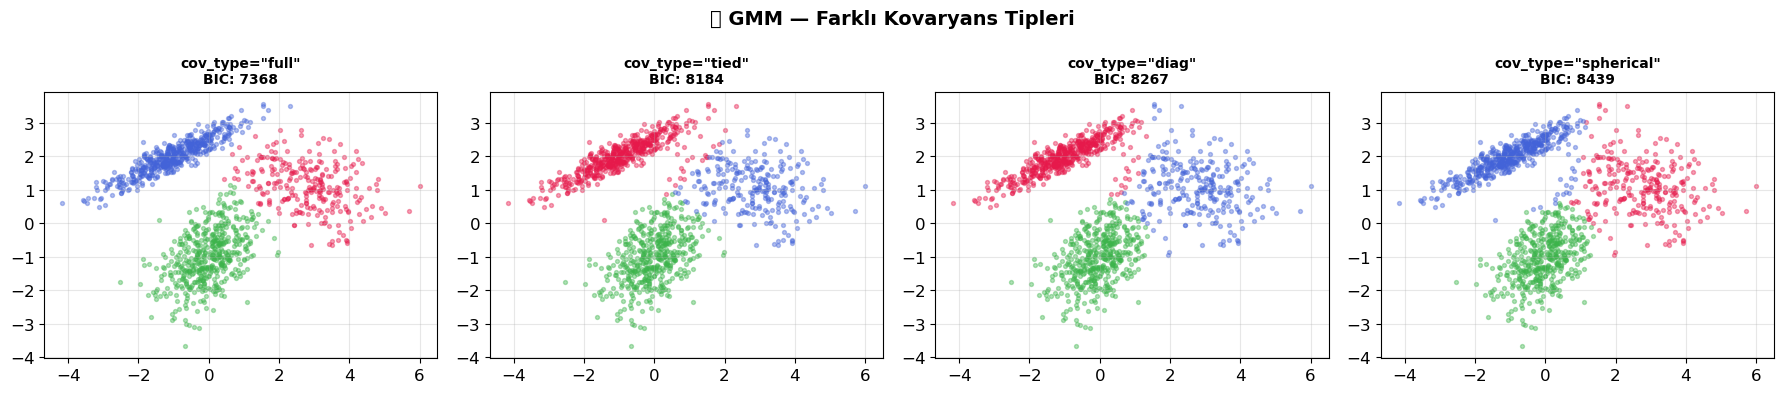

In [17]:
# Farklı covariance_type değerlerini karşılaştır
covariance_types = ['full', 'tied', 'diag', 'spherical']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, cov_type in zip(axes, covariance_types):
    gm_cov = GaussianMixture(n_components=3, covariance_type=cov_type, 
                              n_init=10, random_state=42)
    y_cov = gm_cov.fit_predict(X_gmm)
    score = gm_cov.bic(X_gmm)
    
    for i in range(3):
        ax.scatter(X_gmm[y_cov==i, 0], X_gmm[y_cov==i, 1],
                   c=colors[i], alpha=0.4, s=8)
    ax.set_title(f'cov_type="{cov_type}"\nBIC: {score:.0f}', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('🔧 GMM — Farklı Kovaryans Tipleri', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Kovaryans Tipi Karşılaştırması

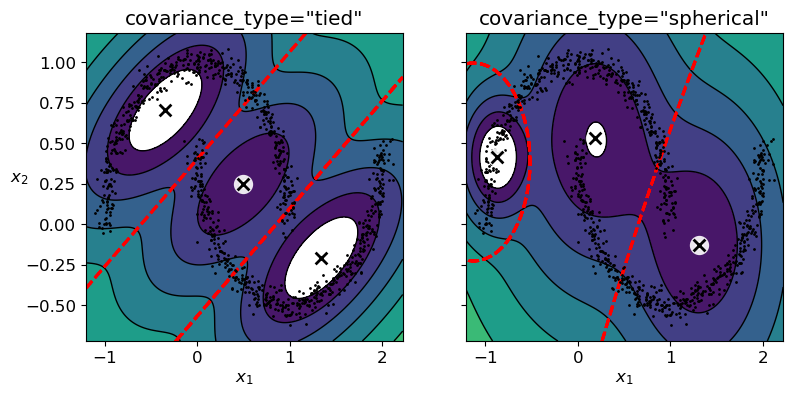

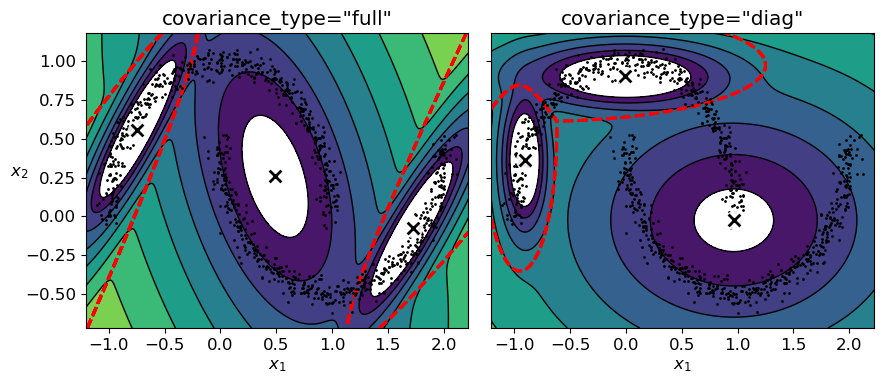

In [55]:
gm_full     = GaussianMixture(n_components=3, n_init=10, covariance_type="full",     random_state=42)
gm_tied     = GaussianMixture(n_components=3, n_init=10, covariance_type="tied",     random_state=42)
gm_spherical= GaussianMixture(n_components=3, n_init=10, covariance_type="spherical",random_state=42)
gm_diag     = GaussianMixture(n_components=3, n_init=10, covariance_type="diag",     random_state=42)
for gm_model in [gm_full, gm_tied, gm_spherical, gm_diag]:
    gm_model.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))
    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')
    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)
plt.show()
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

---

### 7.2 GMM ile Anomali Tespiti

**Fikir:** Düşük yoğunluklu bölgelerdeki örnekler anomalidir!

**Adımlar:**
1. GMM modelini eğit
2. Her örnek için `score_samples()` ile log-PDF değeri hesapla
3. Belirli bir eşiğin altındaki örnekleri anomali olarak işaretle

**Pratik Not:** Beklenen anomali oranı (örn. %2) eşiği belirlemek için kullanılabilir.

🎯 Anomali Tespiti Sonuçları:
  Toplam örnek: 1250
  Tespit edilen anomali: 50 (%4.0)
  Yoğunluk eşiği (log-PDF): -5.144


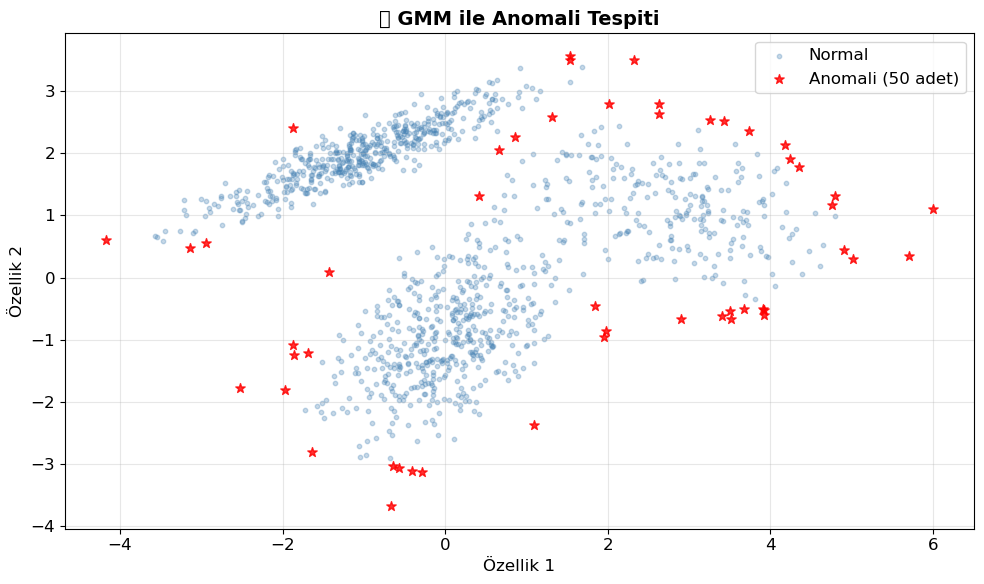

In [18]:
# GMM ile Anomali Tespiti

# Yoğunluk skorlarını hesapla
densities = gm.score_samples(X_gmm)

# Eşik: En düşük %4'ü anomali say
density_threshold = np.percentile(densities, 4)
anomalies = X_gmm[densities < density_threshold]
normal = X_gmm[densities >= density_threshold]

print(f"🎯 Anomali Tespiti Sonuçları:")
print(f"  Toplam örnek: {len(X_gmm)}")
print(f"  Tespit edilen anomali: {len(anomalies)} (%{len(anomalies)/len(X_gmm)*100:.1f})")
print(f"  Yoğunluk eşiği (log-PDF): {density_threshold:.3f}")

plt.figure(figsize=(10, 6))
plt.scatter(normal[:, 0], normal[:, 1], c='steelblue', alpha=0.3, s=10, label='Normal')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', alpha=0.8, 
            s=50, marker='*', label=f'Anomali ({len(anomalies)} adet)', zorder=5)
plt.title('🚨 GMM ile Anomali Tespiti', fontsize=14, fontweight='bold')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Anomali Tespiti vs. Yenilik Tespiti

| Tür | Açıklama |
|-----|----------|
| **Anomali Tespiti** | Eğitim verisi aykırı değer içerebilir |
| **Yenilik Tespiti** | Eğitim verisi temiz; test verisindeki yeni kalıpları tespit eder |

**İpucu:** Eğer çok fazla aykırı değer varsa model "normalliği" yanlış öğrenebilir. Bu durumda:
1. Modeli bir kez eğit
2. Aykırıları tespit edip çıkar
3. Temizlenmiş veriyle tekrar eğit

---

### 7.3 Optimal Küme Sayısını Seçmek: BIC ve AIC

K-Means'in inertia ve silhouette skoru GMM için güvenilir değildir. Bunun yerine **teorik bilgi kriterleri** kullanılır:

$$\text{BIC} = \log(m) \cdot p - 2\log(\hat{\mathcal{L}})$$

$$\text{AIC} = 2p - 2\log(\hat{\mathcal{L}})$$

- **m**: Örnek sayısı
- **p**: Öğrenilen parametre sayısı
- **L̂**: Maksimize edilmiş olabilirlik (likelihood) değeri

**Düşük BIC/AIC = Daha iyi model**  
BIC çok büyük veri setlerinde daha sade modeli tercih eder; AIC biraz daha karmaşık modelleri kabul edebilir.

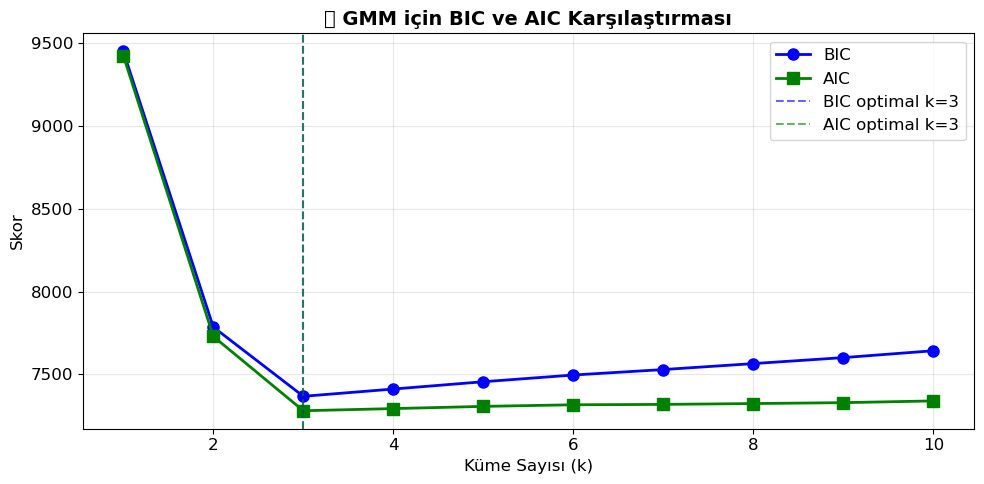

BIC'e göre optimal k: 3
AIC'e göre optimal k: 3


In [19]:
# BIC ve AIC ile optimal küme sayısı
bic_scores = []
aic_scores = []
k_values = range(1, 11)

for k in k_values:
    gm_k = GaussianMixture(n_components=k, n_init=10, random_state=42)
    gm_k.fit(X_gmm)
    bic_scores.append(gm_k.bic(X_gmm))
    aic_scores.append(gm_k.aic(X_gmm))

optimal_k_bic = list(k_values)[np.argmin(bic_scores)]
optimal_k_aic = list(k_values)[np.argmin(aic_scores)]

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), bic_scores, 'bo-', linewidth=2, markersize=8, label='BIC')
plt.plot(list(k_values), aic_scores, 'gs-', linewidth=2, markersize=8, label='AIC')
plt.axvline(x=optimal_k_bic, color='blue', linestyle='--', alpha=0.6, label=f'BIC optimal k={optimal_k_bic}')
plt.axvline(x=optimal_k_aic, color='green', linestyle='--', alpha=0.6, label=f'AIC optimal k={optimal_k_aic}')
plt.xlabel('Küme Sayısı (k)', fontsize=12)
plt.ylabel('Skor', fontsize=12)
plt.title('📊 GMM için BIC ve AIC Karşılaştırması', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"BIC'e göre optimal k: {optimal_k_bic}")
print(f"AIC'e göre optimal k: {optimal_k_aic}")

---

### 7.4 Bayesian Gaussian Karışım Modeli

Optimal k'yı manuel aramak yerine **BayesianGaussianMixture** sınıfı bunu otomatik yapar:

- Gereksiz kümeler otomatik olarak sıfıra yakın ağırlık alır
- Büyük bir k belirtin — algoritma fazlalıkları kendisi eler
- Bayesian yaklaşım sayesinde **aşırı uyumu (overfitting) önler**

In [20]:
# Bayesian GMM - k=10 ile başla, algoritma gerekli olanı bulsun
bgm = BayesianGaussianMixture(n_components=10, n_init=10, 
                               max_iter=500, random_state=42)
bgm.fit(X_gmm)

print("🧠 Bayesian GMM Sonuçları:")
print(f"  Belirtilen maksimum k: 10")
print(f"  Küme ağırlıkları: {bgm.weights_.round(3)}")
print(f"  Sıfıra yakın kümeler: {(bgm.weights_ < 0.01).sum()}")
print(f"  Gerçek anlamlı küme sayısı: {(bgm.weights_ >= 0.01).sum()}")
print("\n💡 Bayesian GMM gereksiz kümeleri otomatik olarak devre dışı bıraktı!")

🧠 Bayesian GMM Sonuçları:
  Belirtilen maksimum k: 10
  Küme ağırlıkları: [0.001 0.392 0.001 0.399 0.208 0.    0.    0.    0.    0.   ]
  Sıfıra yakın kümeler: 7
  Gerçek anlamlı küme sayısı: 3

💡 Bayesian GMM gereksiz kümeleri otomatik olarak devre dışı bıraktı!


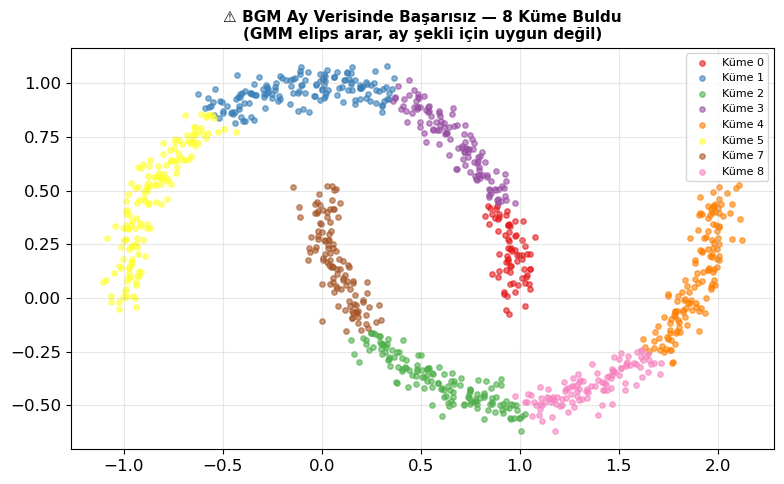

💡 Bu nedenle doğru algoritmayı seçmek kritik önem taşır!


In [21]:
# Bayesian GMM ile ay veri seti - Kısıtlamaları göster
bgm_moons = BayesianGaussianMixture(n_components=10, n_init=5, 
                                     max_iter=200, random_state=42)
y_bgm_moons = bgm_moons.fit_predict(X_moons)

active_clusters = np.unique(y_bgm_moons)

plt.figure(figsize=(8, 5))
cmap = plt.cm.Set1
for i, c in enumerate(active_clusters):
    mask = y_bgm_moons == c
    plt.scatter(X_moons[mask, 0], X_moons[mask, 1], 
                c=[cmap(i/len(active_clusters))], alpha=0.6, s=15, label=f'Küme {c}')
plt.title(f'⚠️ BGM Ay Verisinde Başarısız — {len(active_clusters)} Küme Buldu\n(GMM elips arar, ay şekli için uygun değil)', 
          fontweight='bold', fontsize=11)
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("💡 Bu nedenle doğru algoritmayı seçmek kritik önem taşır!")

---

## 📌 Bölüm 8: Diğer Anomali ve Yenilik Tespit Algoritmaları

### Scikit-Learn'deki Anomali Tespit Araçları:

| Algoritma | Sınıf | Kullanım Durumu |
|-----------|-------|------------------|
| **Fast-MCD** | `EllipticEnvelope` | Tek Gaussian dağılım varsayımı; veri temizleme için |
| **Isolation Forest** | `IsolationForest` | Yüksek boyutlu veri; anomaliler daha az adımda izole edilir |
| **Local Outlier Factor (LOF)** | `LocalOutlierFactor` | Yerel yoğunluk karşılaştırması; k-NN tabanlı |
| **One-Class SVM** | `OneClassSVM` | Yenilik tespiti; yüksek boyutlu veri |
| **PCA + Yeniden Yapılandırma** | `PCA` | Yeniden yapılandırma hatası → Anomali skoru |

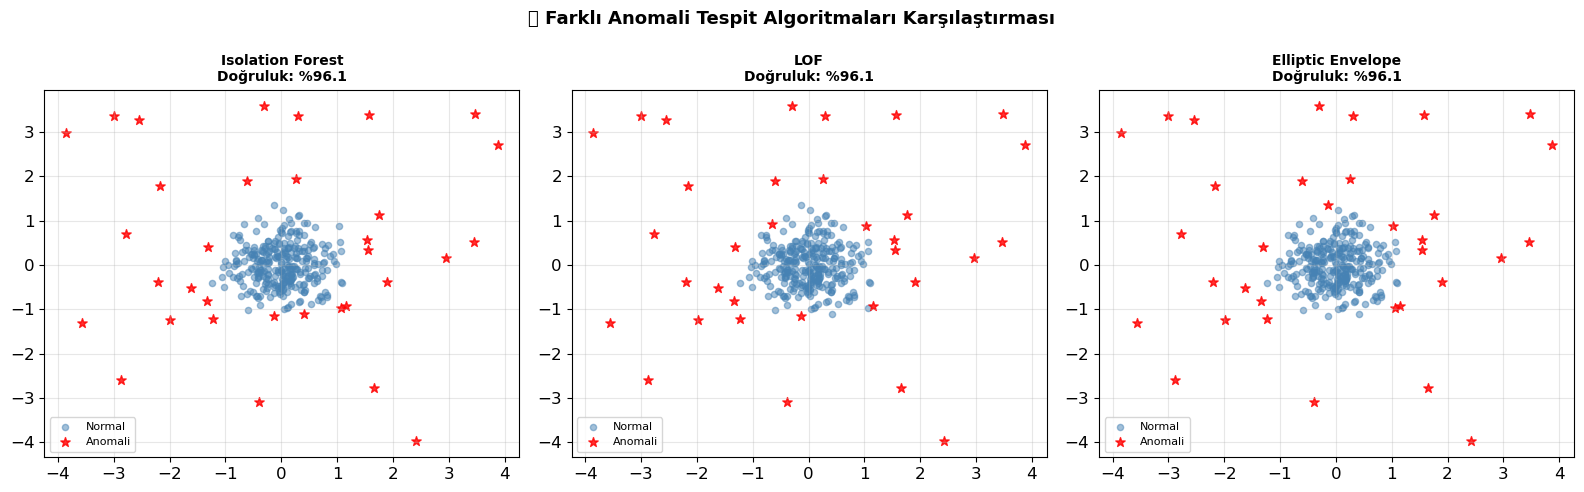

In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

# Test verisi oluştur
np.random.seed(42)
X_normal = np.random.randn(300, 2) * 0.5
X_anom = np.random.uniform(-4, 4, (30, 2))  # Gerçek anomaliler
X_test_all = np.vstack([X_normal, X_anom])
y_true_labels = np.array([1]*300 + [-1]*30)  # 1=normal, -1=anomali

# Farklı algoritmalar
algorithms = {
    'Isolation Forest': IsolationForest(random_state=42, contamination=0.1),
    'LOF': LocalOutlierFactor(n_neighbors=20, contamination=0.1),
    'Elliptic Envelope': EllipticEnvelope(contamination=0.1, random_state=42)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, algo) in zip(axes, algorithms.items()):
    y_pred_algo = algo.fit_predict(X_test_all)
    correct = (y_pred_algo == y_true_labels).mean() * 100
    
    ax.scatter(X_test_all[y_pred_algo == 1, 0], X_test_all[y_pred_algo == 1, 1],
               c='steelblue', alpha=0.5, s=20, label='Normal')
    ax.scatter(X_test_all[y_pred_algo == -1, 0], X_test_all[y_pred_algo == -1, 1],
               c='red', alpha=0.8, s=50, marker='*', label='Anomali')
    ax.set_title(f'{name}\nDoğruluk: %{correct:.1f}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('🚨 Farklı Anomali Tespit Algoritmaları Karşılaştırması', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 📌 Bölüm 9: Olasılık ve Olabilirlik (Likelihood) Kavramı

### Önemli Ayrım

| Kavram | Soru | Sabit Olan | Değişen |
|--------|------|------------|----------|
| **Olasılık (Probability)** | Bu veri gelecekte ne kadar olası? | Parametreler θ | Veri x |
| **Olabilirlik (Likelihood)** | Bu parametreler veriyi açıklamak için ne kadar iyi? | Veri x | Parametreler θ |

### Maksimum Olabilirlik Tahmini (MLE)

Veriyi en iyi açıklayan parametreleri bul:
$$\hat{\theta} = \arg\max_{\theta} \mathcal{L}(\theta | \mathbf{X})$$

Pratikte **log-likelihood** kullanılır çünkü çarpımları toplama dönüştürür:
$$\log \mathcal{L}(\theta | \mathbf{x}^{(1)}, ..., \mathbf{x}^{(m)}) = \sum_i \log f(\mathbf{x}^{(i)}; \theta)$$

### MAP (Maximum A Posteriori) Tahmini

Öncül dağılım bilgisi varsa MLE yerine MAP kullanılır:
$$\hat{\theta}_{MAP} = \arg\max_{\theta} \mathcal{L}(\theta|\mathbf{x}) \cdot g(\theta)$$

MAP, MLE'nin düzenlileştirilmiş (regularized) versiyonu olarak düşünülebilir.

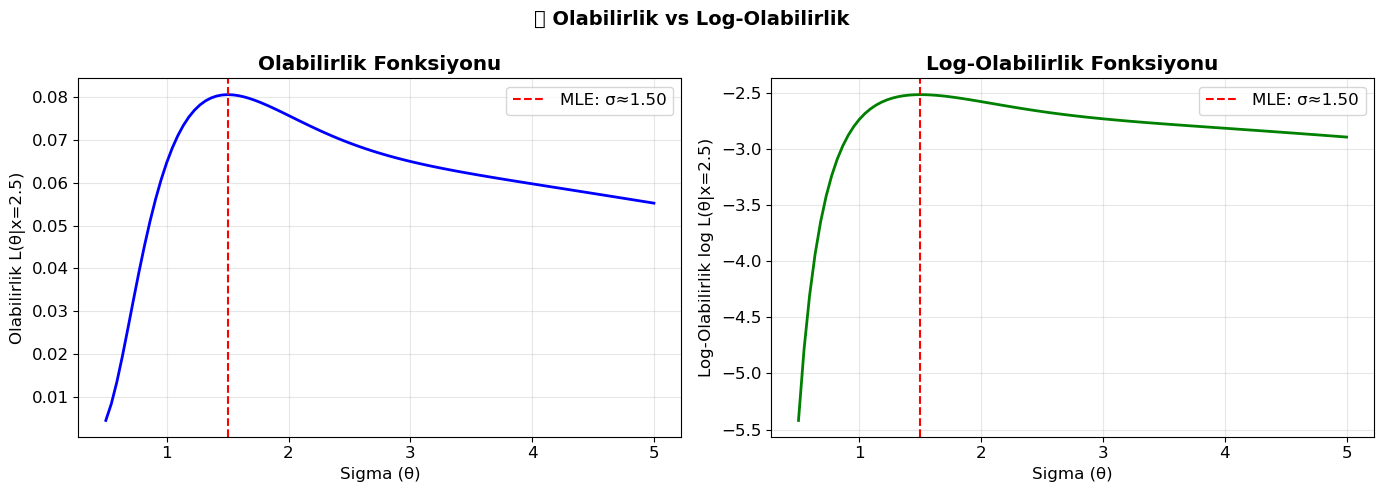

In [23]:
# Olabilirlik fonksiyonunu görselleştir
from scipy.stats import norm

# Gözlemlenen veri noktası
x_observed = 2.5

# Farklı sigma değerleri için likelihood
sigmas = np.linspace(0.5, 5, 100)

# İki Gaussian'ın karışımı
mu1, mu2 = -4, 1
likelihood = [0.5 * norm.pdf(x_observed, mu1, s) + 0.5 * norm.pdf(x_observed, mu2, s) 
              for s in sigmas]
log_likelihood = np.log(likelihood)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sigmas, likelihood, 'b-', linewidth=2)
ax1.axvline(x=sigmas[np.argmax(likelihood)], color='red', linestyle='--', 
            label=f'MLE: σ≈{sigmas[np.argmax(likelihood)]:.2f}')
ax1.set_xlabel('Sigma (θ)', fontsize=12)
ax1.set_ylabel('Olabilirlik L(θ|x=2.5)', fontsize=12)
ax1.set_title('Olabilirlik Fonksiyonu', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(sigmas, log_likelihood, 'g-', linewidth=2)
ax2.axvline(x=sigmas[np.argmax(log_likelihood)], color='red', linestyle='--',
            label=f'MLE: σ≈{sigmas[np.argmax(log_likelihood)]:.2f}')
ax2.set_xlabel('Sigma (θ)', fontsize=12)
ax2.set_ylabel('Log-Olabilirlik log L(θ|x=2.5)', fontsize=12)
ax2.set_title('Log-Olabilirlik Fonksiyonu', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('📈 Olabilirlik vs Log-Olabilirlik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Ödev Çözümü: Olivetti Yüzler

### Veri Yükleme ve Tabakalı Bölme

In [56]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import StratifiedShuffleSplit

olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/livanurkaranfil/scikit_learn_data
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with toleran

In [57]:
# Tabakalı bölme: Her kişiden eşit oranda örnek her sette
strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data, olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

print(f"Eğitim:     {X_train.shape}")
print(f"Doğrulama:  {X_valid.shape}")
print(f"Test:       {X_test.shape}")

Eğitim:     (280, 4096)
Doğrulama:  (80, 4096)
Test:       (40, 4096)


**📌 `StratifiedShuffleSplit` açıklaması:**

```python
StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
```
- `n_splits=1` → Yalnızca 1 bölme üret
- `test_size=40` → Test setinde 40 örnek
- Tabakalı: Her sınıftan (her kişiden) eşit oranda test örneği → Sınıf dengesini korur

```python
train_valid_idx, test_idx = next(strat_split.split(...))
```
`split()` bir generator döndürür. `next()` ile ilk (ve tek) bölmeyi al.

**İki aşamalı bölme:**
1. 400 → 360 (eğitim+doğrulama) + 40 (test)
2. 360 → 280 (eğitim) + 80 (doğrulama)

###  PCA ve K-Means

In [58]:
from sklearn.decomposition import PCA

pca = PCA(0.99)    # Varyansın %99'unu koru
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca  = pca.transform(X_test)

print(f"Orijinal boyut: {X_train.shape[1]}")
print(f"PCA sonrası:    {pca.n_components_}")

Orijinal boyut: 4096
PCA sonrası:    199


**📌 `PCA(0.99)` Açıklaması:**

Float geçirilince → Varyansın **en az %99'unu** açıklayan minimum bileşen sayısını otomatik seç. 4096 piksel → ~100 bileşene iner!

```python
pca.fit_transform(X_train)   # Öğren + dönüştür (YALNIZCA eğitimde)
pca.transform(X_valid)       # Sadece dönüştür (eğitimden öğrenilen bileşenler kullanılır)
```
Kritik: Test/doğrulama setine `fit()` çağrılmaz — bu veri sızıntısını önler.

In [59]:
k_range = range(5, 150, 5)
kmeans_per_k_olivetti = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train_pca)
    kmeans_per_k_olivetti.append(km)
    print(f"k={k}", end=" ")

k=5 k=10 k=15 k=20 k=25 k=30 k=35 k=40 k=45 k=50 k=55 k=60 k=65 k=70 k=75 k=80 k=85 k=90 k=95 k=100 k=105 k=110 k=115 k=120 k=125 k=130 k=135 k=140 k=145 

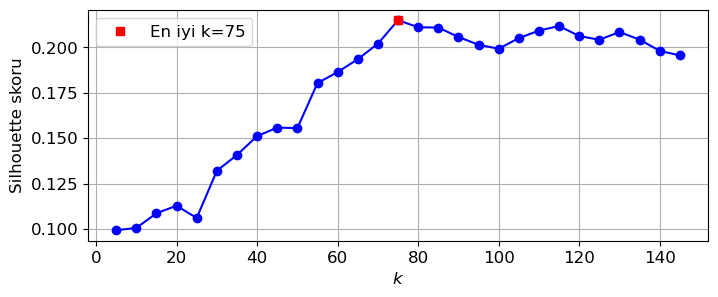


En iyi k: 75


In [60]:
# Silhouette ile en iyi k
sil_scores = [silhouette_score(X_train_pca, m.labels_)
              for m in kmeans_per_k_olivetti]
best_index = np.argmax(sil_scores)
best_k = list(k_range)[best_index]
best_score = sil_scores[best_index]

plt.figure(figsize=(8, 3))
plt.plot(k_range, sil_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette skoru")
plt.plot(best_k, best_score, "rs", label=f"En iyi k={best_k}")
plt.legend()
plt.grid()
plt.show()

best_model = kmeans_per_k_olivetti[best_index]
print(f"\nEn iyi k: {best_k}")

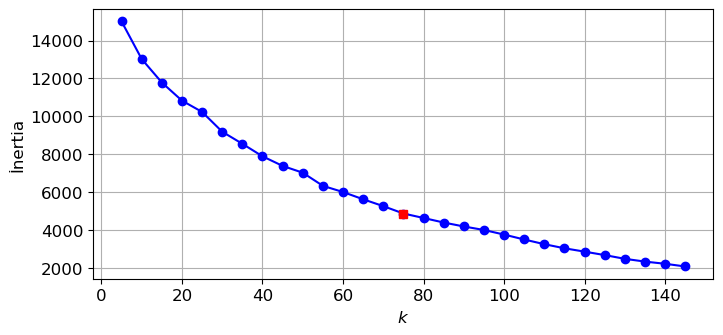

In [61]:
# İnertia grafiği
inertias_olivetti = [m.inertia_ for m in kmeans_per_k_olivetti]
best_inertia = inertias_olivetti[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias_olivetti, "bo-")
plt.xlabel("$k$")
plt.ylabel("İnertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

###  Kümeleri Görselleştirme

Küme 0:


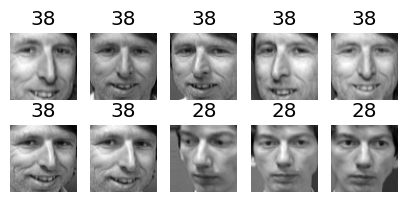

Küme 1:


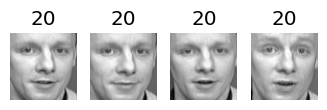

Küme 2:


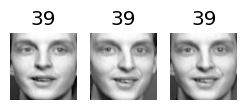

In [62]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_)[:3]:    # İlk 3 küme
    print(f"Küme {cluster_id}:")
    in_cluster = best_model.labels_ == cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

**📌 `plot_faces` açıklaması:**

```python
faces = faces.reshape(-1, 64, 64)
```
Düzleştirilmiş `(n, 4096)` → Görüntü `(n, 64, 64)` formatına dönüştür.

```python
n_rows = (len(faces) - 1) // n_cols + 1
```
Kaç satır gerektiğini hesapla: `ceil(n / n_cols)`. Örn: 7 yüz, 5 sütun → (7-1)//5 + 1 = 2 satır.

```python
for index, (face, label) in enumerate(zip(faces, labels)):
```
`zip()` → face ve label'ı eşleştir. `enumerate()` → indeks ekle.

---
## 🌲 Sınıflandırma için K-Means ve Boyut İndirgeme

### Baseline: Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

# PCA özellikleri üzerinde Random Forest
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
print(f"PCA ile doğruluk: {clf.score(X_valid_pca, y_valid):.4f}")

PCA ile doğruluk: 0.9375


In [64]:
# K-Means ile boyut indirgeme
X_train_reduced = best_model.transform(X_train_pca)  # (n_train, k) mesafe matrisi
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced  = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)
print(f"K-Means mesafe özellikleri ile doğruluk: {clf.score(X_valid_reduced, y_valid):.4f}")

K-Means mesafe özellikleri ile doğruluk: 0.7375


**📌 `transform()` burada ne yapıyor?**

Her örnek için tüm küme centroid'lerine olan mesafeyi hesaplar. Eğer best_k=120 ise: `(n, ~100)` → `(n, 120)` — Farklı bir boyut indirgeme!

In [65]:
from sklearn.pipeline import make_pipeline

print("k değerine göre doğruluk (ilk 8):")
for n_clusters in list(k_range)[:8]:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42)
    )
    pipeline.fit(X_train_pca, y_train)
    score = pipeline.score(X_valid_pca, y_valid)
    print(f"  k={n_clusters:3d}: {score:.4f}")

k değerine göre doğruluk (ilk 8):
  k=  5: 0.4000
  k= 10: 0.4375
  k= 15: 0.5875
  k= 20: 0.6000
  k= 25: 0.6625
  k= 30: 0.6625
  k= 35: 0.6625
  k= 40: 0.6750


**📌 `make_pipeline` açıklaması:**

```python
make_pipeline(KMeans(...), RandomForestClassifier(...))
```
Pipeline, adımları sırayla uygular:
1. `KMeans.fit_transform(X)` → Mesafe matrisi oluştur
2. `RandomForestClassifier.fit(X_mesafe)` → Sınıflandırıcıyı eğit

`pipeline.fit()` her iki adımı sırayla çalıştırır.

In [66]:
# Özellik birleştirme: PCA + K-Means mesafeleri
X_train_extended = np.c_[X_train_pca, X_train_reduced]   # Yatayda birleştir
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended  = np.c_[X_test_pca,  X_test_reduced]

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
print(f"PCA + K-Means birleşik özellikler: {clf.score(X_valid_extended, y_valid):.4f}")

PCA + K-Means birleşik özellikler: 0.8500


**📌 `np.c_` açıklaması:**

```python
X_train_extended = np.c_[X_train_pca, X_train_reduced]
```
`np.c_` → Sütunları yan yana birleştir (column-wise concatenate).
- `X_train_pca` shape: `(280, ~100)`
- `X_train_reduced` shape: `(280, k)`
- `X_train_extended` shape: `(280, ~100+k)` — Her iki temsili birleştir

---
## 🎨  GMM ile Yüz Üretimi

### GMM Eğitimi ve Yeni Yüzler Üretme

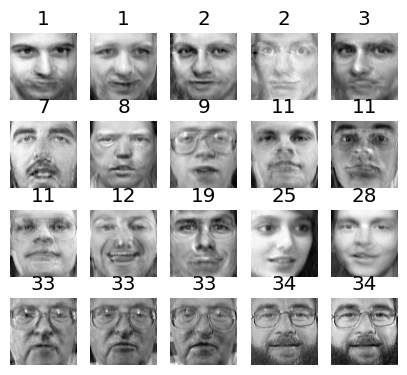

In [67]:
gm_faces = GaussianMixture(n_components=40, random_state=42)
y_pred_faces = gm_faces.fit_predict(X_train_pca)

# Yeni yüzler üret
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm_faces.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)   # PCA uzayı → piksel uzayı

plot_faces(gen_faces, y_gen_faces)

**📌 Açıklama:**

```python
gm_faces = GaussianMixture(n_components=40, random_state=42)
y_pred_faces = gm_faces.fit_predict(X_train_pca)
```
40 Gaussian bileşeniyle GMM eğit. 40 kişi var → mantıklı bir seçim.

```python
gen_faces_reduced, y_gen_faces = gm_faces.sample(n_samples=n_gen_faces)
```
GMM'den 20 yeni yüz örnekle — bunlar PCA uzayında (düşük boyutlu).

```python
gen_faces = pca.inverse_transform(gen_faces_reduced)
```
PCA uzayından piksel uzayına geri dönüştür: `(20, ~100)` → `(20, 4096)`

---
## Anomali Tespiti: Bozulmuş Yüzler

### Bozulmuş Yüzler Oluşturma

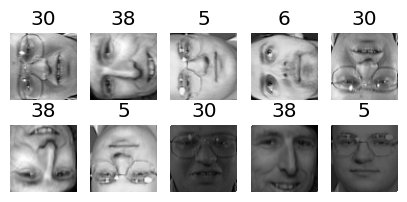

In [68]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

**📌 Görüntü Bozma İşlemleri:**

```python
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
```
- `.reshape(-1, 64, 64)` → Düzleştirilmiş → 2D görüntü
- `np.transpose(..., axes=[0, 2, 1])` → 64×64 matrisi 90° döndür (satır-sütun değiştir)

```python
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
```
- `[:, ::-1]` → Her 64×64 görüntüde satırları ters çevir → yatay eksende aynalama

```python
darkened[:, 1:-1] *= 0.3
```
- `[:, 1:-1]` → Tüm örnekler, ilk ve son sütun hariç tüm pikseller
- `*= 0.3` → Piksel değerlerini %30'a düşür → görüntü kararır

In [69]:
# GMM ile anomali tespiti
X_bad_faces_pca = pca.transform(X_bad_faces)

print("Bozulmuş yüz log-PDF skorları:")
print(gm_faces.score_samples(X_bad_faces_pca))

print("\nNormal yüz log-PDF skorları (ilk 10):")
print(gm_faces.score_samples(X_train_pca[:10]))

Bozulmuş yüz log-PDF skorları:
[-1.85962655e+07 -1.73014235e+07 -4.15206840e+07 -4.81260091e+07
 -3.20479529e+07 -1.35426595e+07 -2.92373914e+07 -9.25150602e+07
 -1.03272550e+08 -5.41697737e+07]

Normal yüz log-PDF skorları (ilk 10):
[1163.02021048 1112.17308304 1156.3213291  1170.67602808 1073.69246254
 1139.89252933 1113.76630128 1073.69245015 1048.17522909 1048.17520792]


**📌 Açıklama:**

```python
gm_faces.score_samples(X_bad_faces_pca)
```
Bozulmuş yüzler çok düşük log-PDF → GMM bu görüntülerin "nadir" olduğunu anlıyor.

```python
gm_faces.score_samples(X_train_pca[:10])
```
Normal yüzler çok yüksek log-PDF → Model bunları biliyor.

**Sonuç:** GMM ile eşik belirleyerek anomali tespiti yapılabilir!

---
## PCA ile Yeniden Yapılandırma Hatası

### PCA Reconstruction Error

In [70]:
# PCA özellikleri (zaten hesaplanmış)
print("PCA özellikleri (ilk 3 örnek, ilk 5 bileşen):")
print(X_train_pca.round(2)[:3, :5])

PCA özellikleri (ilk 3 örnek, ilk 5 bileşen):
[[ -3.78   1.85  -5.14  -1.     3.06]
 [-10.15   1.53  -0.77   1.49  -1.77]
 [ 10.02  -2.88  -0.92   1.32   2.82]]


In [71]:
def reconstruction_errors(pca, X):
    X_pca = pca.transform(X)                   # Piksel → PCA uzayı
    X_reconstructed = pca.inverse_transform(X_pca)  # PCA → Piksel (yaklaşık)
    mse = np.square(X_reconstructed - X).mean(axis=-1)   # MSE her örnek için
    return mse

print(f"Normal yüzlerin ort. yeniden yapılandırma hatası: {reconstruction_errors(pca, X_train).mean():.6f}")
print(f"Bozulmuş yüzlerin ort. yeniden yapılandırma hatası: {reconstruction_errors(pca, X_bad_faces).mean():.6f}")

Normal yüzlerin ort. yeniden yapılandırma hatası: 0.000192
Bozulmuş yüzlerin ort. yeniden yapılandırma hatası: 0.004707


**📌 Fonksiyon açıklaması:**

```python
X_reconstructed = pca.inverse_transform(pca.transform(X))
```
PCA → Düşük boyut → Geri dönüştür → Bu yaklaşık bir yeniden yapılandırma. Bilgi kaybolduğundan tam orijinal alınamaz.

```python
mse = np.square(X_reconstructed - X).mean(axis=-1)
```
- `X_reconstructed - X` → Her piksel için fark
- `np.square(...)` → Farkların karesi
- `.mean(axis=-1)` → Her görüntü için ortalama → shape `(n_örnekler,)`

**Beklenti:** Normal yüzler düşük hata, bozulmuş yüzler yüksek hata.

Bozulmuş yüzler (orijinal):


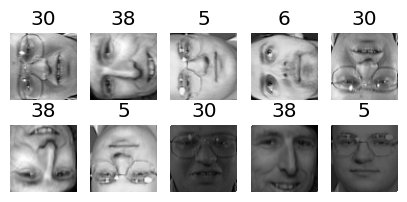

Yeniden yapılandırılmış yüzler (PCA'dan):


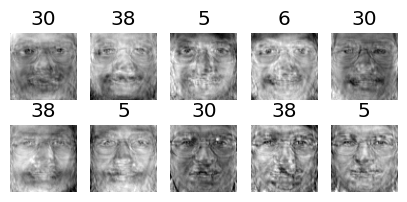

In [72]:
# Bozulmuş ve yeniden yapılandırılmış yüzleri karşılaştır
print("Bozulmuş yüzler (orijinal):")
plot_faces(X_bad_faces, y_bad)

X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
print("Yeniden yapılandırılmış yüzler (PCA'dan):")
plot_faces(X_bad_faces_reconstructed, y_bad)

**📌 Açıklama:**

```python
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
```
PCA önceki bileşenlerle bozulmuş görüntüyü "en makul" normal yüze dönüştürmeye çalışır. Döndürülmüş yüzü geri döndürür, karartılmışı aydınlatır — PCA'nın öğrendiği "normal yüz uzayına" yansıtır!

**Bu anomali tespiti için kullanılabilir:** Yüksek yeniden yapılandırma hatası = anormal görüntü.

---
## 📋 ÖZET: Tüm Metodların Hızlı Başvuru Tablosu

| Metod | Açıklama | Döndürdüğü |
|-------|----------|-----------|
| `KMeans.fit(X)` | Modeli eğit | `self` |
| `KMeans.predict(X)` | Küme indeksi | `(n,)` |
| `KMeans.fit_predict(X)` | Eğit + tahmin et | `(n,)` |
| `KMeans.transform(X)` | Centroid mesafeleri | `(n, k)` |
| `KMeans.fit_transform(X)` | Eğit + mesafe | `(n, k)` |
| `KMeans.score(X)` | Negatif inertia | `float` |
| `KMeans.inertia_` | Eğitim inertia | `float` |
| `KMeans.cluster_centers_` | Centroid koordinatları | `(k, n)` |
| `KMeans.labels_` | Eğitim etiketleri | `(m,)` |
| `DBSCAN.labels_` | Küme etiketleri (-1=anomali) | `(m,)` |
| `DBSCAN.core_sample_indices_` | Çekirdek örnek indeksleri | `(n_core,)` |
| `DBSCAN.components_` | Çekirdek örnek koordinatları | `(n_core, n)` |
| `GaussianMixture.predict(X)` | Sert kümeleme | `(n,)` |
| `GaussianMixture.predict_proba(X)` | Yumuşak kümeleme | `(n, k)` |
| `GaussianMixture.sample(n)` | Yeni örnekler üret | `(n, d), (n,)` |
| `GaussianMixture.score_samples(X)` | Log-PDF | `(n,)` |
| `GaussianMixture.bic(X)` / `.aic(X)` | Bilgi kriteri | `float` |
| `silhouette_score(X, labels)` | Ortalama silhouette | `float` |
| `silhouette_samples(X, labels)` | Bireysel silhouette | `(n,)` |

---


---

## 🎯 Hızlı Başvuru Kılavuzu

```python
# ── K-Means ──────────────────────────────────────────────
from sklearn.cluster import KMeans, MiniBatchKMeans
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_             # Küme etiketleri
centers = kmeans.cluster_centers_   # Küme merkezleri
inertia = kmeans.inertia_           # Atalet skoru
kmeans.predict(X_new)               # Yeni örnekler için tahmin
kmeans.transform(X_new)             # Merkezlere uzaklık (soft clustering)

# ── Silhouette ───────────────────────────────────────────
from sklearn.metrics import silhouette_score, silhouette_samples
score = silhouette_score(X, labels)    # Ortalama silhouette skoru
per_sample = silhouette_samples(X, labels)  # Her örnek için

# ── DBSCAN ───────────────────────────────────────────────
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)
dbscan.labels_               # -1 = anomali
dbscan.core_sample_indices_  # Çekirdek örnek indeksleri
dbscan.components_           # Çekirdek örnekler

# ── GMM ──────────────────────────────────────────────────
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
gm = GaussianMixture(n_components=3, n_init=10, covariance_type='full')
gm.fit(X)
gm.weights_        # Küme ağırlıkları
gm.means_          # Küme ortalamaları
gm.covariances_    # Kovaryans matrisleri
gm.predict(X)      # Sert kümeleme
gm.predict_proba(X)  # Yumuşak kümeleme
gm.sample(n)       # Yeni örnek üretimi
gm.score_samples(X) # Log-PDF (yoğunluk skoru)
gm.bic(X)          # BIC skoru
gm.aic(X)          # AIC skoru

# Anomali tespiti ile GMM
densities = gm.score_samples(X)
threshold = np.percentile(densities, 4)  # En düşük %4
anomalies = X[densities < threshold]
```

---

## 📚 Kaynaklar

- Aurélien Géron, *Hands-On Machine Learning with Scikit-Learn and PyTorch*, 3rd Edition — Chapter 8
- Scikit-Learn Dökümantasyonu: [sklearn.cluster](https://scikit-learn.org/stable/modules/clustering.html)
- Scikit-Learn Dökümantasyonu: [sklearn.mixture](https://scikit-learn.org/stable/modules/mixture.html)
- Arthur & Vassilvitskii, "k-Means++: The Advantages of Careful Seeding" (2007)
- Sculley, "Web-Scale K-Means Clustering" (2010)

---
*Bu notebook, Hands-On ML kitabının 8. bölümündeki tüm kavramları Türkçe açıklamalarla kapsamaktadır.*  
*GitHub'da paylaşım için hazırlanmıştır — MIT Lisansı*